In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import glob
import os
import io
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

In [28]:
customers = pd.read_csv('customers.csv')
geography = pd.read_csv('geography.csv')
inventory = pd.read_csv('inventory.csv')
order_items = pd.read_csv('order_items.csv')
orders = pd.read_csv('orders.csv')
payments = pd.read_csv('payments.csv')
products = pd.read_csv('products.csv')
promotions = pd.read_csv('promotions.csv')
returns = pd.read_csv('returns.csv')
reviews = pd.read_csv('reviews.csv')
sales = pd.read_csv('sales.csv')
shipments = pd.read_csv('shipments.csv')
web_traffic = pd.read_csv('web_traffic.csv')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17472\1196294731.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('order_items.csv')


1. DESCRIPTIVE

REVENUE TREND OVER TIME

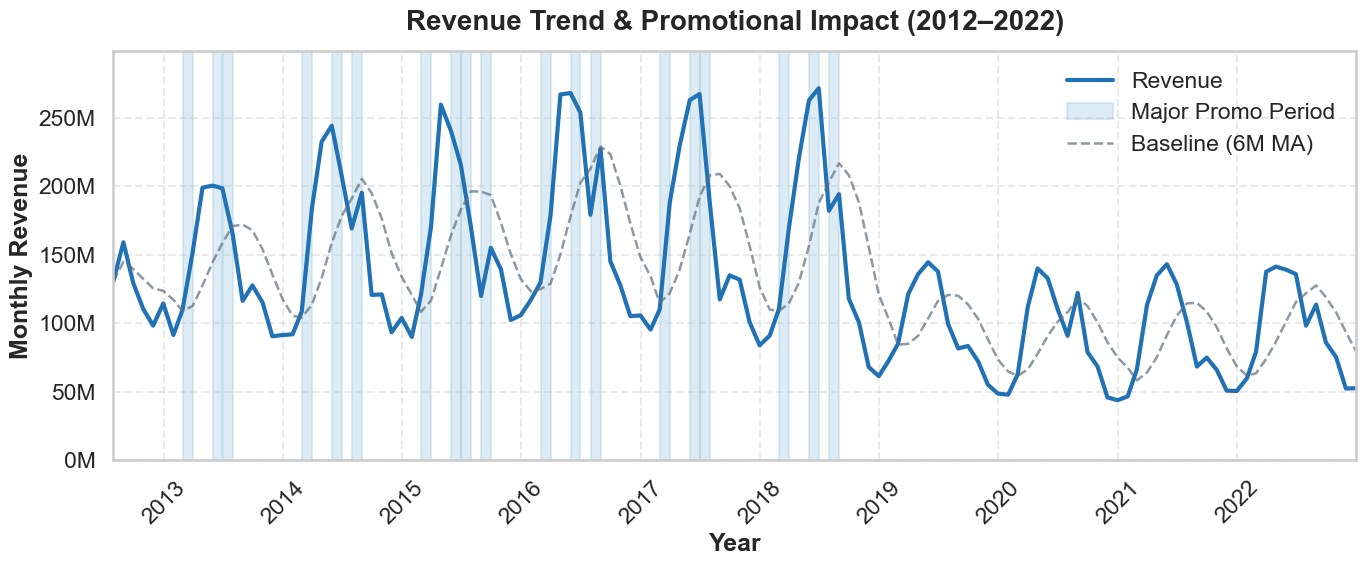

In [29]:
# 1. DATA PREP
orders['order_date'] = pd.to_datetime(orders['order_date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# MERGE
sales_data = pd.merge(order_items, orders[['order_id', 'order_date']], on='order_id', how='inner')

# REVENUE
sales_data['revenue'] = sales_data['quantity'] * sales_data['unit_price']
sales_data.set_index('order_date', inplace=True)
sales_monthly = sales_data.resample('ME')['revenue'].sum().reset_index()
sales_monthly.rename(columns={'order_date': 'date'}, inplace=True)

# 2. PROMO FLAG
sales_monthly['is_promo'] = 0
for _, row in promotions.iterrows():
    mask = (sales_monthly['date'] >= row['start_date']) & (sales_monthly['date'] <= row['end_date'])
    sales_monthly.loc[mask, 'is_promo'] = 1

# 3. GRAPH
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 6))

# REVENUE LINE
sns.lineplot(
    data=sales_monthly, 
    x='date', 
    y='revenue', 
    color='#2171B5',
    linewidth=3,
    ax=ax,
    label='Revenue'
)

# 4. MAJOR PROMOS
promo_months = sales_monthly[sales_monthly['is_promo'] == 1]
major_promo_threshold = promo_months['revenue'].quantile(0.75)
major_promos = promo_months[promo_months['revenue'] >= major_promo_threshold]

for i, date in enumerate(major_promos['date']):
    # Find the 1st day of the month for the section's start point
    month_start = date.replace(day=1)
    
    ax.axvspan(
        month_start, 
        date, 
        color='#9ECAE1',
        alpha=0.35,
        zorder=1,
        label='Major Promo Period' if i == 0 else "" 
    )

# 5. BASELINE
sales_monthly['baseline'] = sales_monthly['revenue'].rolling(6, min_periods=1).mean()
sns.lineplot(
    data=sales_monthly,
    x='date',
    y='baseline',
    linestyle='--',
    color='#5D6D7E',
    # 9ECAE1
    linewidth=1.8,
    alpha=0.7,
    label='Baseline (6M MA)',
    ax=ax
)

# 6. FORMAT
ax.set_title(
    'Revenue Trend & Promotional Impact (2012–2022)',
    fontsize=20, fontweight='bold', pad=15
)

ax.set_xlabel('Year', fontsize=18, fontweight='bold')
ax.set_ylabel('Monthly Revenue', fontsize=18, fontweight='bold')

# Y-AXIS
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x / 1e9:,.1f}B'
    return f'{x / 1e6:,.0f}M'
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

# X-AXIS
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.4)

# CLEANUP
ax.legend(frameon=False)
ax.set_xlim(sales_monthly['date'].min(), sales_monthly['date'].max())
ax.set_ylim(0, sales_monthly['revenue'].max() * 1.1)

plt.tight_layout()
plt.show()

CUSTOMER COHORT RETENTION

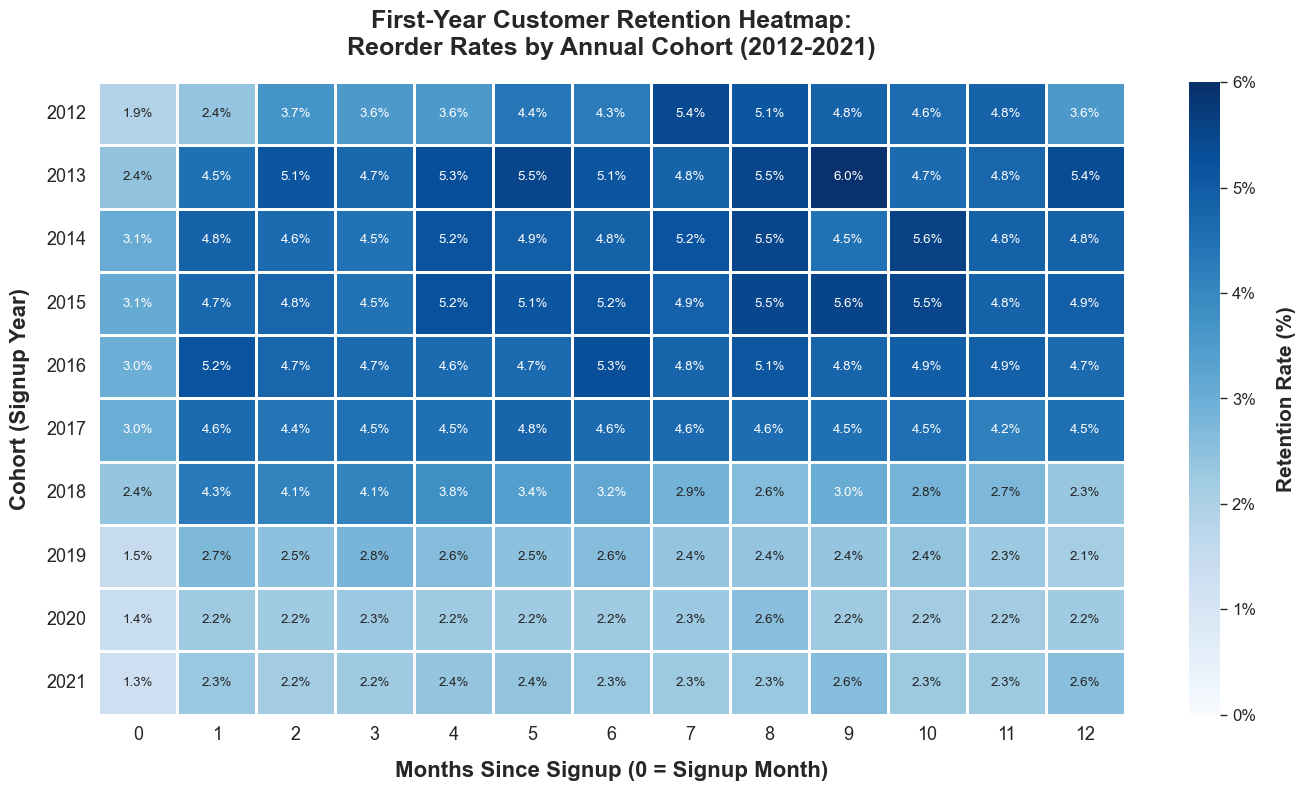

In [30]:
# 1. PREP DATA
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# MERGE
df_cohort = pd.merge(orders, customers[['customer_id', 'signup_date']], on='customer_id', how='inner')
df_cohort = df_cohort[df_cohort['order_date'] >= df_cohort['signup_date']]
df_cohort['CohortYear'] = df_cohort['signup_date'].dt.year

# CALCULATE MONTH DIFF
df_cohort['OrderMonth_dt'] = df_cohort['order_date'].dt.to_period('M')
df_cohort['SignupMonth_dt'] = df_cohort['signup_date'].dt.to_period('M')
df_cohort['MonthsSinceSignup'] = (df_cohort['OrderMonth_dt'] - df_cohort['SignupMonth_dt']).apply(lambda x: x.n)
df_cohort = df_cohort[df_cohort['MonthsSinceSignup'] <= 12]

# Get the TRUE starting size of each Annual Cohort
cohort_sizes = customers.groupby(customers['signup_date'].dt.year)['customer_id'].nunique()
cohort_data = df_cohort.groupby(['CohortYear', 'MonthsSinceSignup'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortYear', columns='MonthsSinceSignup', values='customer_id')

# RETENTION %
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
retention_matrix.index = retention_matrix.index.astype(int).astype(str)
retention_matrix = retention_matrix.drop('2022', errors='ignore')

# 2. VISUALIZATION
sns.set_theme(style="white", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 8)) 
sns.heatmap(
    retention_matrix, 
    annot=True,
    fmt='.1%',
    cmap='Blues',
    # 'YlGnBu'
    vmin=0.0, 
    vmax=0.06   ,
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=1,
    linecolor='white',
    ax=ax
)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Retention Rate (%)', size=15, weight='bold', labelpad=15)

ax.set_title('First-Year Customer Retention Heatmap:\nReorder Rates by Annual Cohort (2012-2021)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Months Since Signup (0 = Signup Month)', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Cohort (Signup Year)', fontweight='bold', fontsize=16, labelpad=12)

plt.yticks(rotation=0, fontsize=13)
plt.xticks(fontsize=13)

plt.tight_layout()
plt.show()

2. DIAGNOSTIC

PROMOTIONS IMPACT

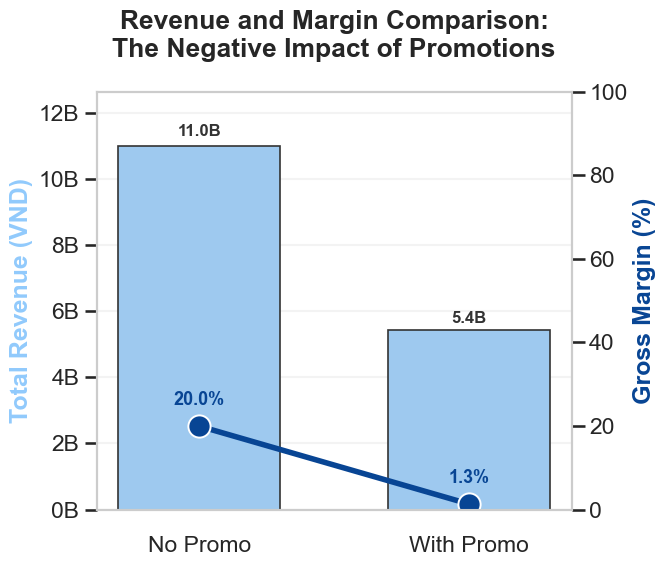

In [31]:
df_promo = pd.merge(order_items, products[['product_id', 'cogs', 'category']], on='product_id', how='left')
df = pd.merge(df_promo, promotions[['promo_id', 'promo_type']], on='promo_id', how='left')

# CLASSIFY ORDERS WITH OR WITHOUT PROMOTIONS
df_promo['has_promo'] = df_promo['promo_id'].notnull() | df_promo['promo_id_2'].notnull()

# CALCULATE REVENUE AND COGS
df_promo['Revenue'] = df_promo['quantity'] * df_promo['unit_price']
df_promo['Total_COGS'] = df_promo['quantity'] * df_promo['cogs']
df_promo['Profit'] = df_promo['Revenue'] - df_promo['Total_COGS']

# GROSS MARGIN %
summary = df_promo.groupby('has_promo').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
}).reset_index()
summary['Gross_Margin_%'] = (summary['Profit'] / summary['Revenue']) * 100
summary['has_promo'] = summary['has_promo'].map({True: 'With Promo', False: 'No Promo'})

# GRAPH
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(7, 6))

color_revenue = "#91CAFC"
color_margin = '#084594'
color_spine = '#CCCCCC'

# 1. Revenue Bar Chart
sns.barplot(data=summary, x='has_promo', y='Revenue', color=color_revenue, ax=ax1, 
            edgecolor='#333333', width=0.6, linewidth=1.2)

# Format Y-axis
def billions_formatter(x, pos):
    return f'{x / 1e9:,.0f}B'
ax1.yaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax1.set_ylim(0, summary['Revenue'].max() * 1.15)
ax1.set_ylabel('Total Revenue (VND)', color=color_revenue, fontweight='bold', fontsize=18)
ax1.set_xlabel('')
ax1.tick_params(axis='x', pad=10)

# Data Labels
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height + (height * 0.02),
             f'{height / 1e9:,.1f}B',
             ha="center", va="bottom", color='#333333', fontweight='bold', fontsize=12)

# 2. Profit Margin Line
ax2 = ax1.twinx()
sns.lineplot(data=summary, x='has_promo', y='Gross_Margin_%',
             color=color_margin, marker='o', linewidth=4, markersize=16, ax=ax2,
             markeredgecolor='white', markeredgewidth=1.4)

ax2.set_ylabel('Gross Margin (%)', color=color_margin, fontweight='bold', fontsize=18)
max_margin = summary['Gross_Margin_%'].max()
ax2.set_ylim(0, 100)

# Data Labels
for i in range(summary.shape[0]):
    margin_val = summary['Gross_Margin_%'][i]
    ax2.text(i, margin_val + 4, f'{margin_val:,.1f}%',
             ha="center", va="bottom", color=color_margin, fontweight='bold', fontsize=13)

plt.title('Revenue and Margin Comparison:\nThe Negative Impact of Promotions',
          fontsize=19, fontweight='bold', pad=25)

for ax in [ax1, ax2]:
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color_spine)
        ax.spines[spine].set_linewidth(1.5)
ax1.grid(axis='y', linestyle='-', color='#F0F0F0', alpha=0.8)

plt.tight_layout()
plt.show()

GROSS MARGIN BY PROMO TYPE & CAT

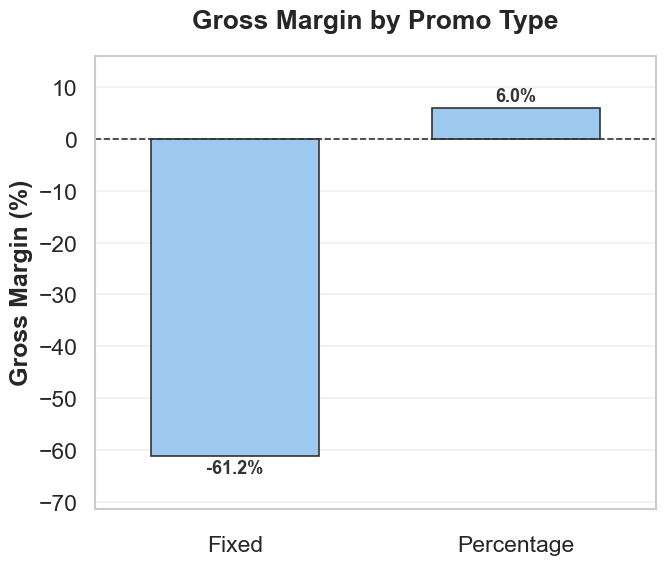

In [32]:
# 1. DATA PREP
df_promo_only = df_promo[df_promo['has_promo'] == True].copy()
df_promo_only = pd.merge(df_promo_only, promotions[['promo_id', 'promo_type']], on='promo_id', how='left')
df_promo_only['promo_type'] = df_promo_only['promo_type'].str.title()

promo_type_stats = df_promo_only.groupby('promo_type').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
}).reset_index()
promo_type_stats['Gross_Margin_%'] = (promo_type_stats['Profit'] / promo_type_stats['Revenue']) * 100


# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(7, 6))

color_bar = "#91CAFC"
color_label = "#000000"
color_spine = '#CCCCCC'

# BAR CHART
sns.barplot(data=promo_type_stats, x='promo_type', y='Gross_Margin_%', 
            color=color_bar, ax=ax1, 
            edgecolor='#333333', width=0.6, linewidth=1.2)

ax1.axhline(0, color='#333333', linewidth=1.2, linestyle='--')

# FORMAT AXES
ax1.set_ylabel('Gross Margin (%)', fontweight='bold', fontsize=18)
ax1.set_xlabel('')
ax1.tick_params(axis='x', pad=10)

# Y-LIMITS
y_min, y_max = promo_type_stats['Gross_Margin_%'].min(), promo_type_stats['Gross_Margin_%'].max()
padding = (y_max - y_min) * 0.15
ax1.set_ylim(y_min - padding, y_max + padding)

# DATA LABELS
for p in ax1.patches:
    height = p.get_height()
    if height >= 0:
        va = 'bottom'
        offset = padding * 0.05
    else:
        va = 'top'
        offset = -padding * 0.05
    ax1.text(p.get_x() + p.get_width()/2., height + offset,
             f'{height:,.1f}%',
             ha="center", va=va, color='#333333', fontweight='bold', fontsize=13)

# TITLE
plt.title('Gross Margin by Promo Type', fontsize=19, fontweight='bold', pad=20)

for spine in ['top', 'bottom', 'left', 'right']:
    ax1.spines[spine].set_visible(True)
    ax1.spines[spine].set_color(color_spine)
    ax1.spines[spine].set_linewidth(1.5)

ax1.grid(axis='y', linestyle='-', color='#F0F0F0', alpha=0.8)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.show()

RETURN REASON x CAT

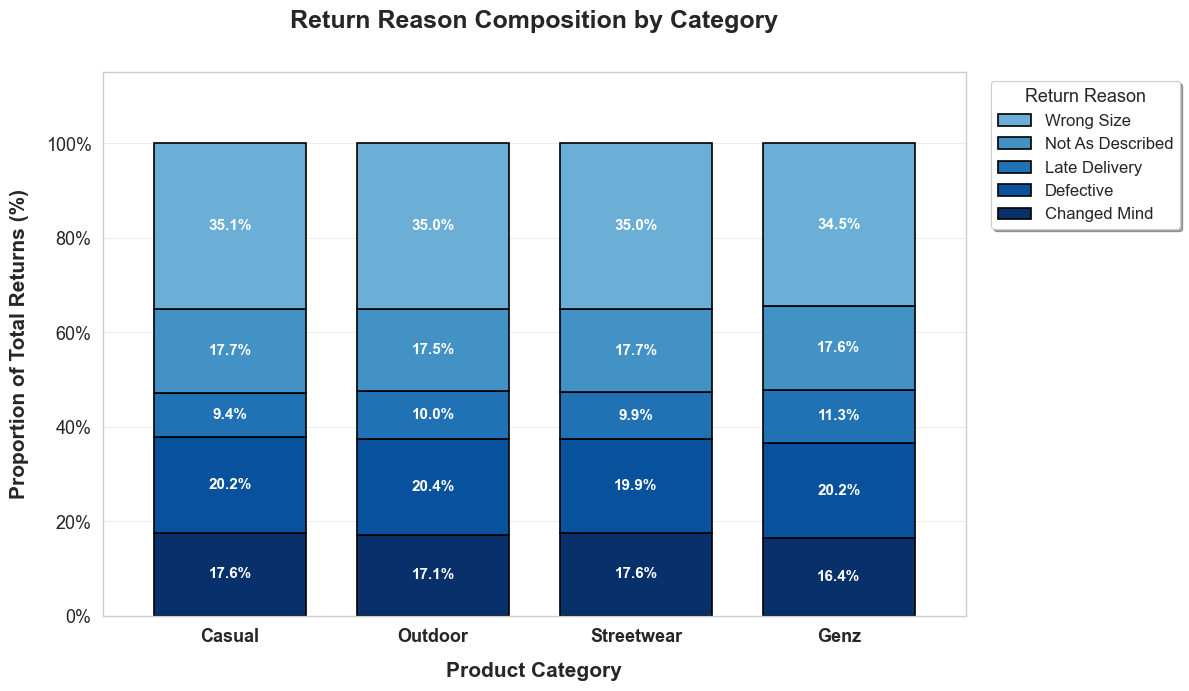

In [33]:
# 1. PREP DATA
df_returns = pd.merge(returns, products[['product_id', 'category']], on='product_id', how='left')
df_returns['category'] = df_returns['category'].str.replace('-', ' ').str.title()
df_returns['return_reason'] = df_returns['return_reason'].str.replace('-', ' ').str.title()

return_counts = df_returns.groupby(['category', 'return_reason']).size().unstack(fill_value=0)
return_counts.columns = [str(col).replace('_', ' ').title() for col in return_counts.columns]
return_pct = return_counts.div(return_counts.sum(axis=1), axis=0) * 100

if 'Wrong Size' in return_pct.columns:
    return_pct = return_pct.sort_values(by='Wrong Size', ascending=False)

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12,7))

colors = ['#08306B', '#08519C', '#2171B5', '#4292C6', '#6BAED6', '#9ECAE1']
colors = colors[:len(return_pct.columns)]

return_pct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=ax,
    width=0.75,
    edgecolor='black',
    linewidth=1.2
)

streetwear_idx = list(return_pct.index).index('Streetwear') if 'Streetwear' in return_pct.index else -1

# DATA LABELS
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 5 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=11)

ax.set_title('Return Reason Composition by Category\n', 
             fontsize=18, fontweight='bold', pad=13)
ax.set_xlabel('Product Category', fontweight='bold', fontsize=15, labelpad=12)
ax.set_ylabel('Proportion of Total Returns (%)', fontweight='bold', fontsize=15, labelpad=12)

# Y-AXIS
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
plt.yticks(fontsize=13)

# X-AXIS
ax.set_xticklabels(return_pct.index, rotation=0, fontsize=13, fontweight='bold')

# LEGEND
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title='Return Reason', title_fontsize=13, fontsize=12, 
           bbox_to_anchor=(1.02, 1.0), loc='upper left', frameon=True, shadow=True)

ax.grid(True, axis='y', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)
ax.grid(False, axis='x')    
ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()

DELIVERY TIME -> RATING -> RETURN CHAIN

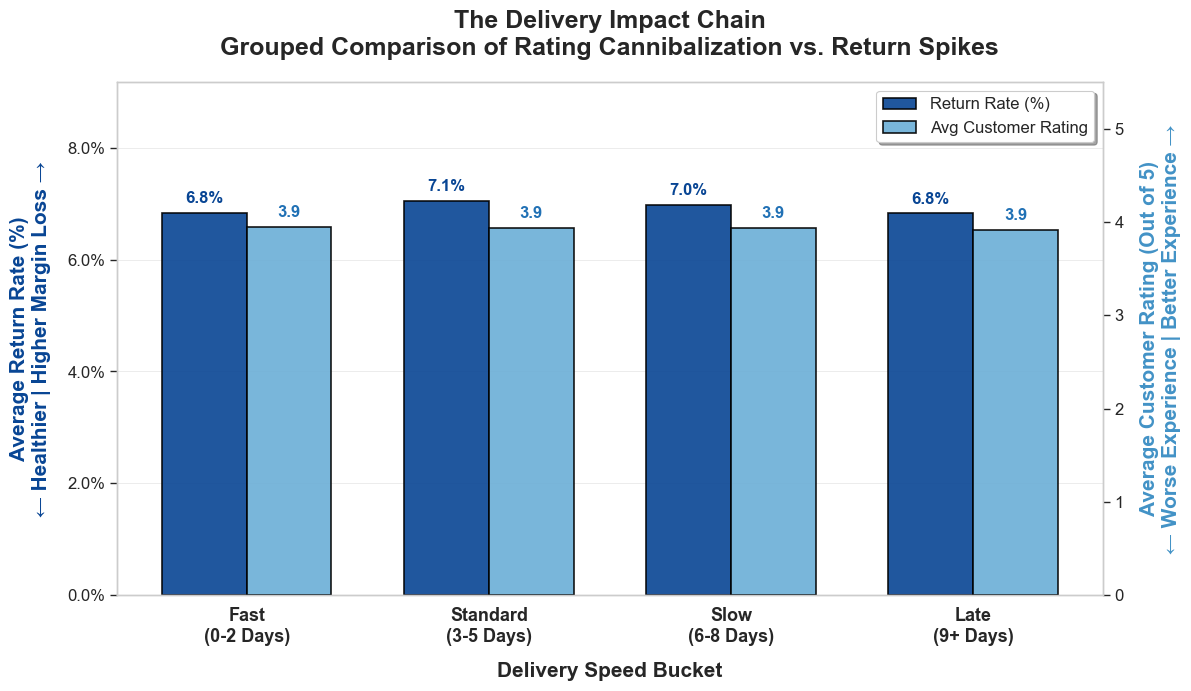

In [34]:
# MERGE DATA CHAIN
df_chain = pd.merge(orders[['order_id', 'order_date']], shipments[['order_id', 'delivery_date']], on='order_id', how='inner')
df_chain = pd.merge(df_chain, reviews[['order_id', 'rating']], on='order_id', how='left')

# FLAG
returns['is_returned'] = 1
df_chain = pd.merge(df_chain, returns[['order_id', 'is_returned']], on='order_id', how='left')
df_chain['is_returned'] = df_chain['is_returned'].fillna(0)

# DELIVERY TIME
df_chain['order_date'] = pd.to_datetime(df_chain['order_date'])
df_chain['delivery_date'] = pd.to_datetime(df_chain['delivery_date'])
df_chain['delivery_days'] = (df_chain['delivery_date'] - df_chain['order_date']).dt.days
df_chain = df_chain.dropna(subset=['delivery_days'])

# DELIVERY SPEED BUCKETS
bins = [-1, 2, 5, 8, float('inf')]
labels = ['Fast\n(0-2 Days)', 'Standard\n(3-5 Days)', 'Slow\n(6-8 Days)', 'Late\n(9+ Days)']
df_chain['delivery_bucket'] = pd.cut(df_chain['delivery_days'], bins=bins, labels=labels)

chain_stats = df_chain.groupby('delivery_bucket', observed=False).agg(
    return_rate=('is_returned', 'mean'),
    avg_rating=('rating', 'mean')
).reset_index()

chain_stats['return_rate_%'] = chain_stats['return_rate'] * 100

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# SET UP THE GROUPED BARS
x = np.arange(len(labels))
width = 0.35 


color_returns = '#084594'
color_rating = '#6BAED6'

# Plot Return Rate (Left Axis)
rects1 = ax1.bar(
    x - width/2, 
    chain_stats['return_rate_%'], 
    width, 
    label='Return Rate (%)', 
    color=color_returns, 
    edgecolor='black', 
    linewidth=1.2,
    alpha=0.9
)

# Plot Average Rating (Right Axis)
rects2 = ax2.bar(
    x + width/2, 
    chain_stats['avg_rating'], 
    width, 
    label='Avg Customer Rating', 
    color=color_rating, 
    edgecolor='black', 
    linewidth=1.2,
    alpha=0.9
)

# FORMATTING LEFT AXIS (RETURN RATE)
ax1.set_ylabel('Average Return Rate (%)\n← Healthier | Higher Margin Loss →', 
               fontweight='bold', fontsize=15, color=color_returns, labelpad=12)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=1))
ax1.set_ylim(0, chain_stats['return_rate_%'].max() * 1.3)
ax1.tick_params(axis='y', labelsize=12)

# FORMATTING RIGHT AXIS (RATING)
ax2.set_ylabel('Average Customer Rating (Out of 5)\n← Worse Experience | Better Experience →', 
               fontweight='bold', fontsize=15, color='#4292C6', labelpad=12)
ax2.set_ylim(0, 5.5)
ax2.tick_params(axis='y', labelsize=12)

# FORMATTING X-AXIS
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold', fontsize=13)
ax1.set_xlabel('Delivery Speed Bucket', fontweight='bold', fontsize=15, labelpad=12)

# DATA LABELS
for rect in rects1:
    height = rect.get_height()
    ax1.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', color=color_returns, fontsize=12)

for rect in rects2:
    height = rect.get_height()
    ax2.annotate(f'{height:.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', color='#2171B5', fontsize=12)

# CLEANUP
ax1.set_title('The Delivery Impact Chain\nGrouped Comparison of Rating Cannibalization vs. Return Spikes', 
              fontsize=18, fontweight='bold', pad=20)
ax1.grid(True, axis='y', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)
ax1.grid(False, axis='x')
ax2.grid(False)

# LEGEND
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True, fontsize=12, shadow=True)

plt.tight_layout()
plt.show()

MARKETING

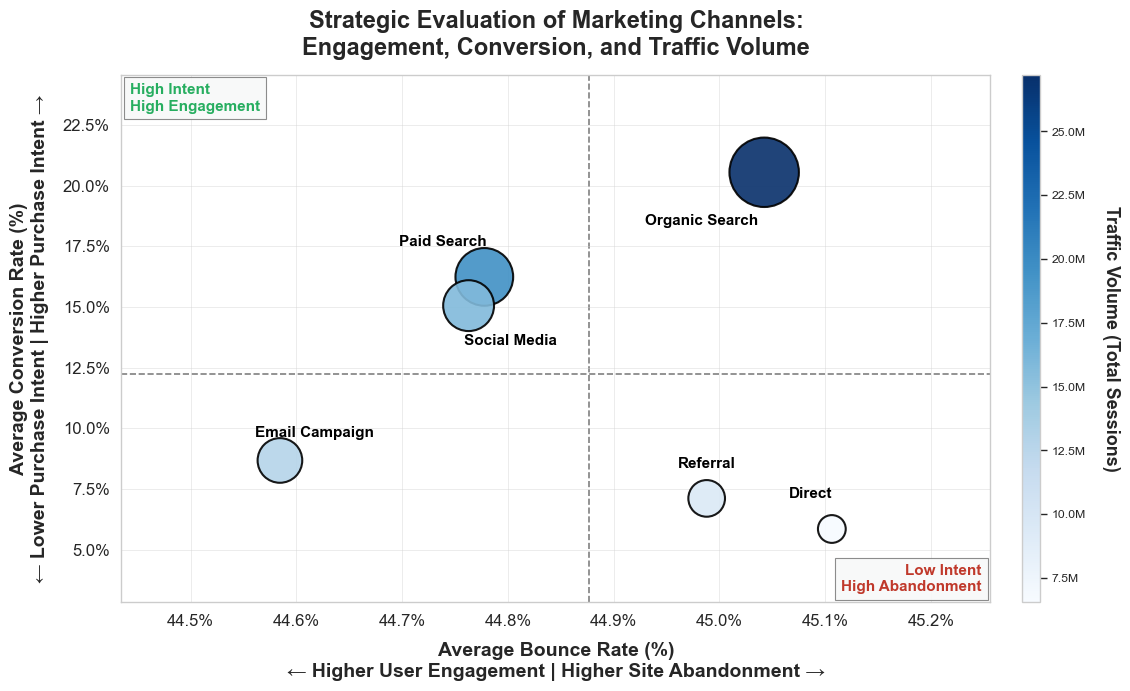

In [35]:
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# 1. FIND CONVERSION RATE
daily_orders = orders.groupby(['order_date', 'order_source'])['order_id'].count().reset_index()
daily_orders.rename(columns={
    'order_date': 'date',
    'order_source': 'traffic_source',
    'order_id': 'total_orders'
}, inplace=True)

traffic_merged = pd.merge(web_traffic, daily_orders, on=['date', 'traffic_source'], how='left')
# FILL MISSING VALUES (DAYS THAT HAD TRAFFIC BUT NO SALE)
traffic_merged['total_orders'] = traffic_merged['total_orders'].fillna(0)
# CONVERSION RATE
traffic_merged['conversion_rate'] = traffic_merged['total_orders'] / traffic_merged['sessions']

# 2. AGGREGATE MARKETING PERFORMANCE BY SOURCE
source_stats = traffic_merged.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_conversion_rate=('conversion_rate', 'mean')
).reset_index()
source_stats['avg_bounce_rate_%'] = source_stats['avg_bounce_rate'] * 100
source_stats['avg_conversion_rate_%'] = source_stats['avg_conversion_rate'] * 100
source_stats['traffic_source_clean'] = source_stats['traffic_source'].str.replace('_', ' ').str.title()

# 3. GRAPH
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 7))

scatter = sns.scatterplot(
    data=source_stats,
    x='avg_bounce_rate_%',
    y='avg_conversion_rate_%',
    size='total_sessions',
    sizes=(400, 2500),
    hue='total_sessions',
    palette='Blues',
    # 'OrRd'
    alpha=0.9,
    edgecolor='black',
    linewidth=1.5,
    ax=ax
)

ax.set_xlim(source_stats['avg_bounce_rate_%'].min() - 0.0015,
            source_stats['avg_bounce_rate_%'].max() + 0.0015)
ax.set_ylim(source_stats['avg_conversion_rate_%'].min() - 0.03,
            source_stats['avg_conversion_rate_%'].max() + 0.04)

# QUADRANT
x_mid = source_stats['avg_bounce_rate_%'].mean()
y_mid = source_stats['avg_conversion_rate_%'].mean()
ax.axvline(x_mid, color='grey', linestyle='--', linewidth=1.2, zorder=0)
ax.axhline(y_mid, color='grey', linestyle='--', linewidth=1.2, zorder=0)
ax.grid(True, which='major', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)

# BG TEXT
bbox_props = dict(boxstyle="square,pad=0.4", fc="#F8F9F9", ec="grey", alpha=0.9)
x_left = ax.get_xlim()[0] + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.02
x_right = ax.get_xlim()[1] - (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.02
y_top = ax.get_ylim()[1] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
y_bottom = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02

ax.text(0.01, 0.985, 'High Intent\nHigh Engagement',
        transform=ax.transAxes, ha='left', va='top',
        color='#27AE60', fontsize=11, fontweight='bold', bbox=bbox_props)
ax.text(0.99, 0.015, 'Low Intent\nHigh Abandonment',
        transform=ax.transAxes, ha='right', va='bottom',
        color='#C0392B', fontsize=11, fontweight='bold', bbox=bbox_props)

# % AXES
def percent_formatter(x, pos):
    val = x * 100 if x <= 1.0 else x
    return f"{val:.1f}%"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(percent_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(percent_formatter))
ax.tick_params(axis='both', labelsize=12)

# OFFSET
custom_offsets = {
    'Organic Search': (-45, -35),
    'Paid Search': (-30, 25),
    'Social Media': (30, -25),
    'Email Campaign': (25, 20),
    'Referral': (0, 25),
    'Direct': (-15, 25)
}

for i in range(source_stats.shape[0]):
    source_name = source_stats['traffic_source_clean'][i]
    offset = custom_offsets.get(source_name, (0, 15))
    ax.annotate(
        source_name,
        (source_stats['avg_bounce_rate_%'][i], source_stats['avg_conversion_rate_%'][i]),
        xytext=offset,
        textcoords='offset points',
        ha='center',
        va='center',
        color='black',
        weight='bold',
        fontsize=11
    )

# TITLE
ax.set_title('Strategic Evaluation of Marketing Channels:\nEngagement, Conversion, and Traffic Volume',
             fontsize=17, fontweight='bold', pad=15)
ax.set_xlabel('Average Bounce Rate (%)\n← Higher User Engagement | Higher Site Abandonment →',
              fontweight='bold', fontsize=14, labelpad=10)
ax.set_ylabel('Average Conversion Rate (%)\n← Lower Purchase Intent | Higher Purchase Intent →',
              fontweight='bold', fontsize=14, labelpad=10)

ax.get_legend().remove()

# COLORBAR
norm = plt.Normalize(source_stats['total_sessions'].min(), source_stats['total_sessions'].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.03, aspect=30)
cbar.set_label('Traffic Volume (Total Sessions)', rotation=270, labelpad=25, fontsize=13, fontweight='bold')

cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x / 1e6:.1f}M"))

plt.tight_layout()
plt.show()

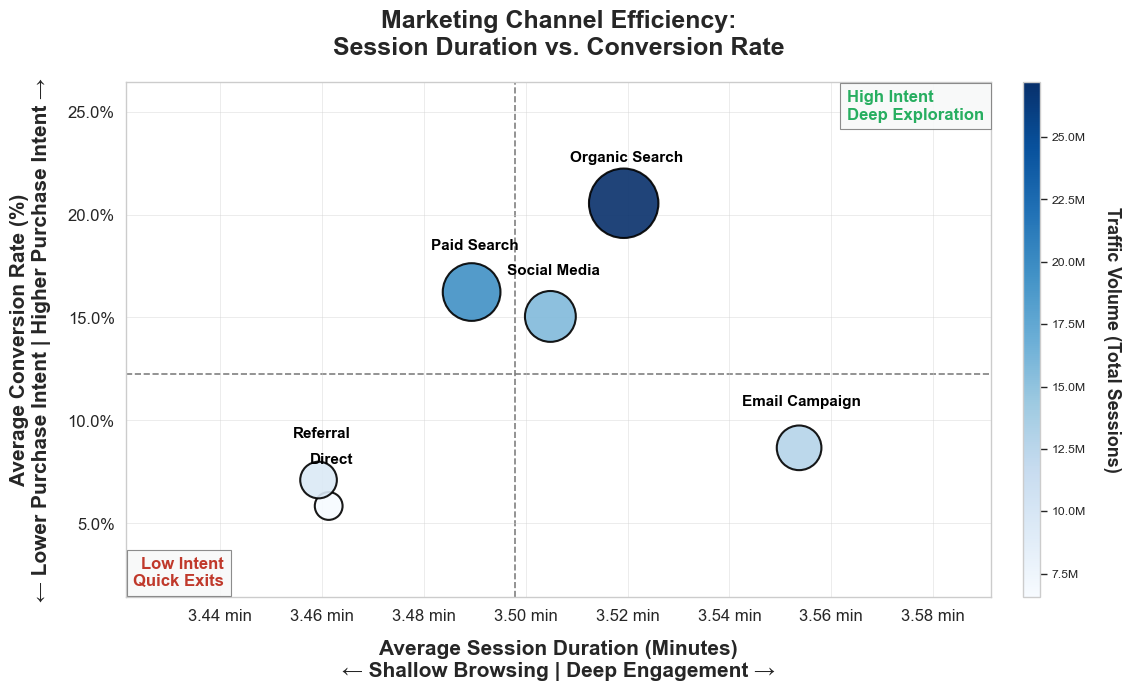

In [36]:

# 1. AGGREGATION FOR SESSION DURATION
source_stats = traffic_merged.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean'),
    avg_conversion_rate=('conversion_rate', 'mean') 
).reset_index()

# TIME CONVERSION
source_stats['avg_session_duration_min'] = source_stats['avg_session_duration_sec'] / 60
source_stats['avg_conversion_rate_%'] = source_stats['avg_conversion_rate'] * 100
source_stats['traffic_source_clean'] = source_stats['traffic_source'].str.replace('_', ' ').str.title()

# 2. GRAPH
sns.set_theme(style="whitegrid", context="paper") 
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 7))

scatter = sns.scatterplot(
    data=source_stats, 
    x='avg_session_duration_min',
    y='avg_conversion_rate_%', 
    size='total_sessions', 
    sizes=(400, 2500),         
    hue='total_sessions',      
    palette='Blues',            
    alpha=0.9, 
    edgecolor='black',
    linewidth=1.5,             
    ax=ax
)

# DYNAMIC BOUNDING BOX
x_min = source_stats['avg_session_duration_min'].min()
x_max = source_stats['avg_session_duration_min'].max()
x_range = x_max - x_min

y_min = source_stats['avg_conversion_rate_%'].min()
y_max = source_stats['avg_conversion_rate_%'].max()
y_range = y_max - y_min

ax.set_xlim(x_min - (x_range * 0.4), x_max + (x_range * 0.4))
ax.set_ylim(y_min - (y_range * 0.3), y_max + (y_range * 0.4))

# QUADRANT LINES
x_mid = source_stats['avg_session_duration_min'].mean()
y_mid = source_stats['avg_conversion_rate_%'].mean()
ax.axvline(x_mid, color='grey', linestyle='--', linewidth=1.2, zorder=0)
ax.axhline(y_mid, color='grey', linestyle='--', linewidth=1.2, zorder=0)

ax.grid(True, which='major', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)

# QUADRANT BOXES
bbox_props = dict(boxstyle="square,pad=0.4", fc="#F8F9F9", ec="grey", alpha=0.9)
ax.text(0.833, 0.985, 'High Intent\nDeep Exploration', 
        transform=ax.transAxes, ha='left', va='top', color='#27AE60', fontsize=12, fontweight='bold', bbox=bbox_props)
ax.text(0.113, 0.015, 'Low Intent\nQuick Exits', 
        transform=ax.transAxes, ha='right', va='bottom', color='#C0392B', fontsize=12, fontweight='bold', bbox=bbox_props)

# FORMAT
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.2f} min"))
def percent_formatter(x, pos):
    val = x * 100 if x <= 1.0 else x
    return f"{val:.1f}%"
ax.yaxis.set_major_formatter(ticker.FuncFormatter(percent_formatter))
ax.tick_params(axis='both', which='major', labelsize=12)

custom_offsets = {
    'Organic Search': (0, 35),
    'Paid Search': (0, 25),
    'Social Media': (0, 25),
    'Email Campaign': (0, 25),
    'Referral': (0, 25),
    'Direct': (0, 25)
}

# LABEL PLACEMENT
for i in range(source_stats.shape[0]):
    ax.annotate(
        source_stats['traffic_source_clean'][i],
        (source_stats['avg_session_duration_min'][i], source_stats['avg_conversion_rate_%'][i]),
        xytext=(2, 28),
        textcoords='offset points',
        ha='center', va='bottom',
        color='black', weight='bold', fontsize=11
    )

ax.set_title('Marketing Channel Efficiency:\nSession Duration vs. Conversion Rate', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Average Session Duration (Minutes)\n← Shallow Browsing | Deep Engagement →', fontweight='bold', fontsize=15, labelpad=12)
ax.set_ylabel('Average Conversion Rate (%)\n← Lower Purchase Intent | Higher Purchase Intent →', fontweight='bold', fontsize=15, labelpad=12)

ax.get_legend().remove()
norm = plt.Normalize(source_stats['total_sessions'].min(), source_stats['total_sessions'].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.03, aspect=30)
cbar.set_label('Traffic Volume (Total Sessions)', rotation=270, labelpad=25, fontweight='bold', fontsize=13)
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x / 1e6:.1f}M"))

plt.tight_layout()
plt.show()

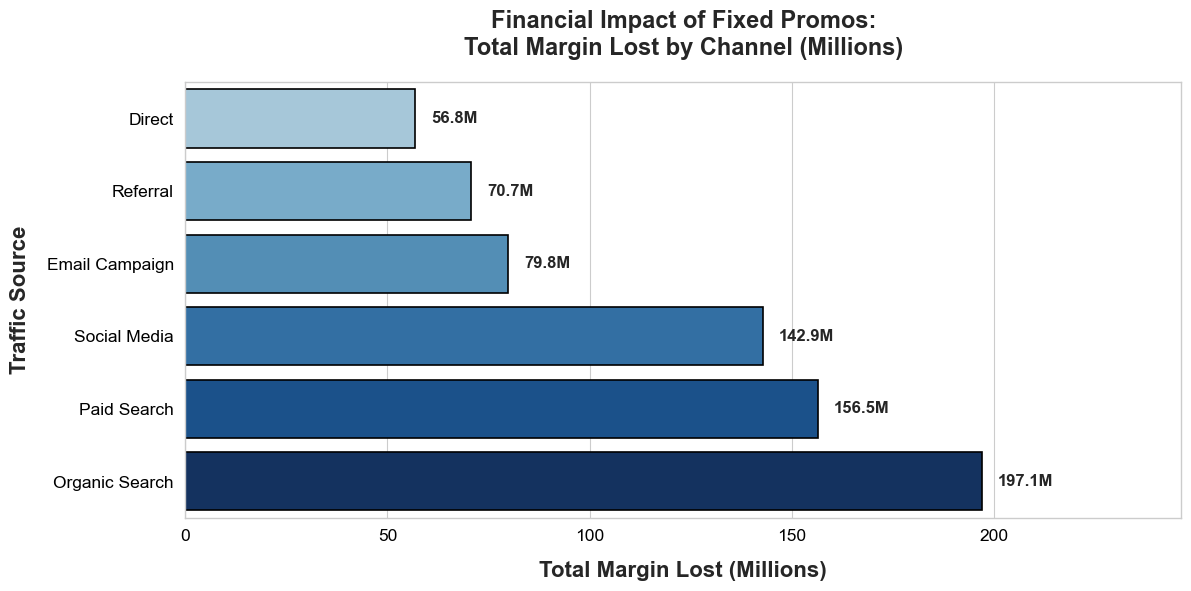

In [37]:
# 1. MERGE DATA
TRAFFIC_COL = 'order_source'

df = pd.merge(order_items, products[['product_id', 'cogs']], on='product_id', how='inner')
df = pd.merge(df, promotions[['promo_id', 'promo_type']], on='promo_id', how='left')
df = pd.merge(df, orders[['order_id', TRAFFIC_COL]], on='order_id', how='inner')

# 2. CALCULATE FINANCIALS & FLAG PROMOS
df['revenue'] = df['quantity'] * df['unit_price']
df['profit'] = df['revenue'] - (df['quantity'] * df['cogs'])
df['promo_type'] = df['promo_type'].fillna('No Promo').str.title()

# 3. CALCULATE ABSOLUTE LOSS
avg_profit_no_promo = df[df['promo_type'] == 'No Promo'].groupby(TRAFFIC_COL)['profit'].mean()
fixed_df = df[df['promo_type'] == 'Fixed']

# Group by source
loss_df = fixed_df.groupby(TRAFFIC_COL).agg(
    fixed_count=('quantity', 'sum'),
    total_fixed_profit=('profit', 'sum')
)
loss_df['expected_profit_no_promo'] = loss_df['fixed_count'] * avg_profit_no_promo

# BLEED
loss_df['total_loss'] = loss_df['expected_profit_no_promo'] - loss_df['total_fixed_profit']

# CLEAN UP
loss_df.index = loss_df.index.str.replace('_', ' ').str.title()
loss_df = loss_df.sort_values('total_loss', ascending=True)

# 4. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

colors = ['#9ECAE1', '#6BAED6', '#4292C6', '#2171B5', '#08519C', '#08306B']

fig, ax = plt.subplots(figsize=(12, 6))

# Scaling to Millions (1e6)
loss_in_millions = loss_df['total_loss'] / 1e6

sns.barplot(
    x=loss_in_millions,
    y=loss_df.index,
    hue=loss_df.index,
    palette=colors,
    legend=False,
    edgecolor='black',
    linewidth=1.2,
    alpha=1.0,
    ax=ax
)

ax.set_title('Financial Impact of Fixed Promos:\nTotal Margin Lost by Channel (Millions)',
             fontsize=17, fontweight='bold', pad=20)
ax.set_xlabel('Total Margin Lost (Millions)', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Traffic Source', fontweight='bold', fontsize=16, labelpad=12)

# LABEL (Updated to M)
max_val = loss_in_millions.max()
for i, v in enumerate(loss_in_millions):
    ax.text(v + (max_val * 0.02), i, f'{v:.1f}M', va='center', fontweight='bold', fontsize=12)

# FORMATTING AXES
ax.tick_params(axis='y', labelsize=12.5, labelcolor='black')
ax.tick_params(axis='x', labelsize=12.5, labelcolor='black')
plt.setp(ax.get_yticklabels(), fontsize=12.5)

ax.set_xlim(0, max_val * 1.25)

plt.tight_layout()
plt.show()

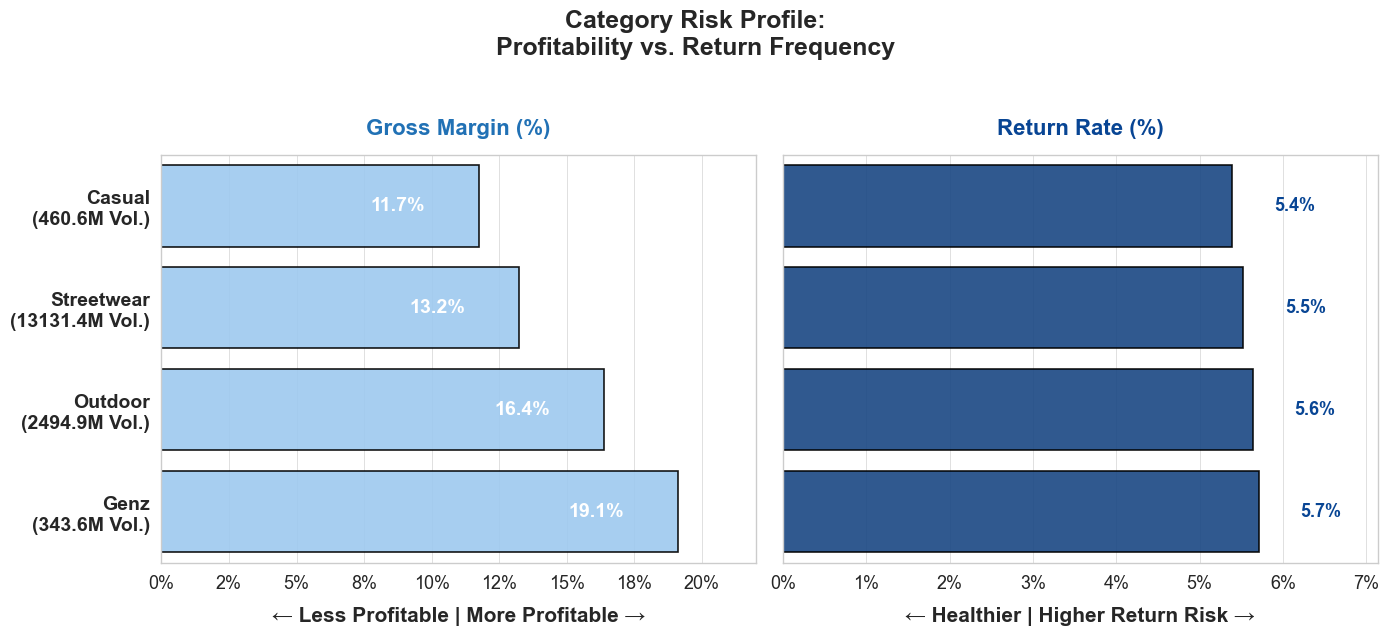

In [38]:
# 2. MERGE & PREP (Aggregating straight to Category level)
df = pd.merge(order_items, products[['product_id', 'cogs', 'category']], on='product_id', how='inner')
returns['is_returned'] = 1
df = pd.merge(df, returns[['order_id', 'product_id', 'is_returned']], on=['order_id', 'product_id'], how='left')
df['is_returned'] = df['is_returned'].fillna(0)

df['revenue'] = df['quantity'] * df['unit_price']
df['profit'] = df['revenue'] - (df['quantity'] * df['cogs'])
df['returned_qty'] = df['quantity'] * df['is_returned']

# 3. AGGREGATE BY CATEGORY
category_stats = df.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    total_qty=('quantity', 'sum'),
    returned_qty=('returned_qty', 'sum')
).reset_index()

category_stats['gross_margin_%'] = (category_stats['total_profit'] / category_stats['total_revenue']) * 100
category_stats['return_rate_%'] = (category_stats['returned_qty'] / category_stats['total_qty']) * 100

# Clean up names and sort from most profitable to least
category_stats['category'] = category_stats['category'].str.replace('_', ' ').str.title()
category_stats = category_stats.sort_values('gross_margin_%', ascending=True)

# Create a rich label that includes the Revenue volume (Added the $ sign back!)
category_stats['cat_label'] = category_stats.apply(
    lambda x: f"{x['category']}\n({x['total_revenue']/1e6:.1f}M Vol.)", axis=1
)

# 4. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

# Create a 1x2 grid for side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

color_margin = '#91CAFC'
# '#91CAFC'
color_return = '#084594'
# '#084594'

# --- PANEL 1: Gross Margin ---
sns.barplot(
    data=category_stats, 
    x='gross_margin_%', 
    y='cat_label', 
    color=color_margin, 
    edgecolor='black', 
    linewidth=1.2, 
    alpha=0.9,
    ax=ax1
)

ax1.set_title('Gross Margin (%)', fontsize=16, fontweight='bold', pad=15, color='#2171B5')
# INCREASED FONT SIZE TO 15
ax1.set_xlabel('← Less Profitable | More Profitable →', fontweight='bold', fontsize=15, labelpad=10)
ax1.set_ylabel('') 
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Data Labels inside the bars
for p in ax1.patches:
    width = p.get_width()
    ax1.text(width - 2, p.get_y() + p.get_height()/2., f'{width:.1f}%', 
             ha="right", va="center", color='white', fontweight='bold', fontsize=14)

# --- PANEL 2: Return Rate ---
sns.barplot(
    data=category_stats, 
    x='return_rate_%', 
    y='cat_label', 
    color=color_return, 
    edgecolor='black', 
    linewidth=1.2, 
    alpha=0.9,
    ax=ax2
)

ax2.set_title('Return Rate (%)', fontsize=16, fontweight='bold', pad=15, color=color_return)
# INCREASED FONT SIZE TO 15
ax2.set_xlabel('← Healthier | Higher Return Risk →', fontweight='bold', fontsize=15, labelpad=10)
ax2.set_ylabel('')
ax2.xaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Data Labels outside the bars
for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 0.5, p.get_y() + p.get_height()/2., f'{width:.1f}%', 
             ha="left", va="center", color=color_return, fontweight='bold', fontsize=13)

# --- FORMATTING ---
fig.suptitle('Category Risk Profile:\nProfitability vs. Return Frequency', 
             fontsize=18, fontweight='bold', y=1.05)

# Scaled up tick label sizes for better readability
ax1.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='x', labelsize=13)
ax2.tick_params(axis='x', labelsize=13)
plt.setp(ax1.get_yticklabels(), fontweight='bold')

ax1.grid(True, axis='x', color='lightgrey', linestyle='-', linewidth=0.5)
ax2.grid(True, axis='x', color='lightgrey', linestyle='-', linewidth=0.5)
ax1.grid(False, axis='y')
ax2.grid(False, axis='y')

# Add some headroom to axes for labels
ax1.set_xlim(0, category_stats['gross_margin_%'].max() * 1.15)
ax2.set_xlim(0, category_stats['return_rate_%'].max() * 1.25)

plt.tight_layout()
plt.show()

INVENTORY HEALTH

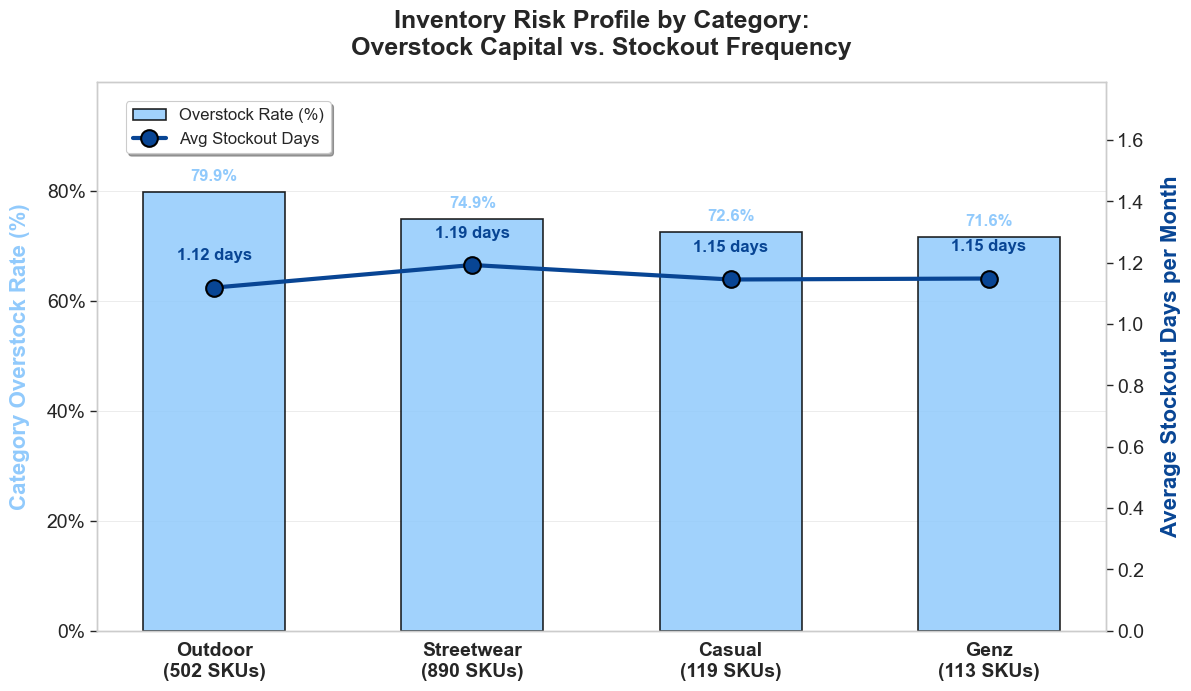

In [39]:
# 1. AGGREGATION
inventory['stockout_days'] = pd.to_numeric(inventory['stockout_days'], errors='coerce').fillna(0)
inventory['overstock_flag'] = pd.to_numeric(inventory['overstock_flag'], errors='coerce').fillna(0)

inv_health = inventory.groupby('category').agg(
    avg_stockout_days=('stockout_days', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    product_count=('product_id', 'nunique')
).reset_index()

inv_health['overstock_rate_%'] = inv_health['overstock_rate'] * 100
inv_health['category_clean'] = inv_health['category'].str.replace('_', ' ').str.title()

inv_health = inv_health.sort_values('overstock_rate_%', ascending=False).reset_index(drop=True)

# 2. GRAPH
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(12, 7))
bars = ax1.bar(
    inv_health['category_clean'],
    inv_health['overstock_rate_%'],
    color="#91CAFC",
    # '#2980B9'
    # '#3498DB'
    alpha=0.85,
    edgecolor='black',
    linewidth=1.2,
    width=0.55,
    label='Overstock Rate (%)'
)

ax1.set_ylabel('Category Overstock Rate (%)',
               fontweight='bold', fontsize=16, color="#91CAFC", labelpad=12)
ax1.set_ylim(0, inv_health['overstock_rate_%'].max() * 1.25)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax1.tick_params(axis='y', labelsize=14)

# % LABELS
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12, color="#91CAFC")

# LINE CHART FOR STOCKOUT DAYS
ax2 = ax1.twinx()
line = ax2.plot(
    inv_health['category_clean'],
    inv_health['avg_stockout_days'],
    color='#084594',
    marker='o',
    markersize=12,
    linewidth=3,
    markeredgecolor='black',
    markeredgewidth=1.5,
    label='Avg Stockout Days'
)

ax2.set_ylabel('Average Stockout Days per Month',
               fontweight='bold', fontsize=16, color='#084594', labelpad=12)
ax2.set_ylim(0, inv_health['avg_stockout_days'].max() * 1.5)
ax2.tick_params(axis='y', labelsize=14)

# LABELS
for i in range(inv_health.shape[0]):
    yval = inv_health['avg_stockout_days'][i]
    ax2.text(i, yval + 0.08, f'{yval:.2f} days',
             ha='center', va='bottom', fontweight='bold', fontsize=12, color='#084594')

# CLEANUP
new_labels = [f"{cat}\n({int(sku)} SKUs)" for cat, sku in zip(inv_health['category_clean'], inv_health['product_count'])]
ax1.set_xticks(range(len(new_labels)))
ax1.set_xticklabels(new_labels, fontweight='bold', fontsize=14)

ax1.set_title('Inventory Risk Profile by Category:\nOverstock Capital vs. Stockout Frequency',
              fontsize=18, fontweight='bold', pad=20)


ax1.grid(True, axis='y', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)
ax1.grid(False, axis='x')
ax2.grid(False)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=12, shadow=True, bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
plt.show()

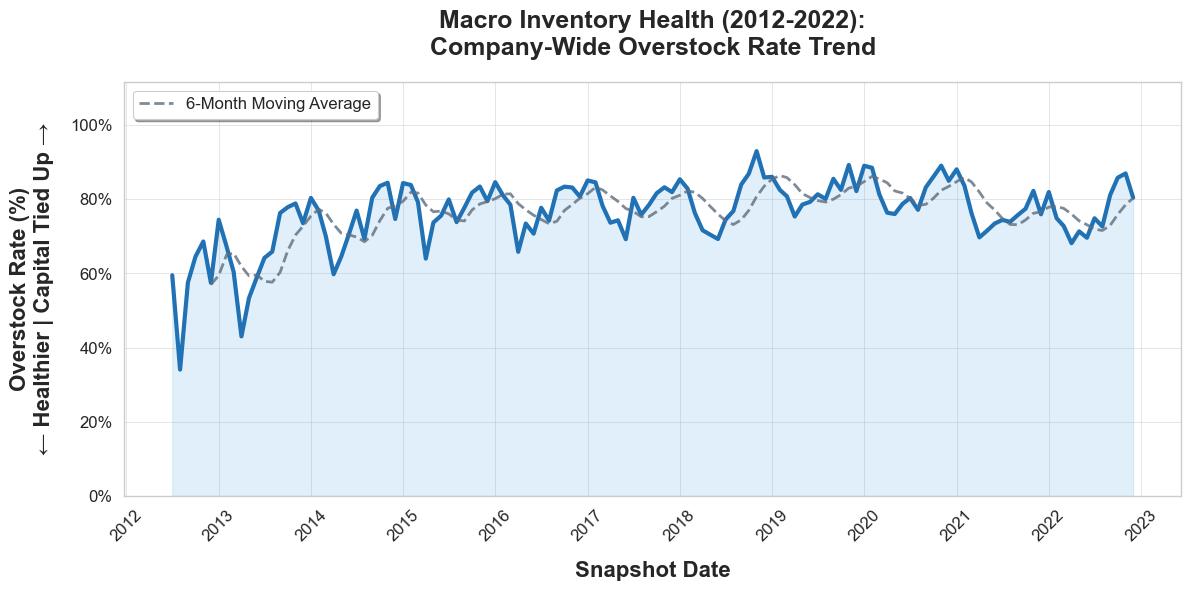

In [40]:
# 1. CLEAN AND AGGREGATE
inventory['overstock_flag'] = pd.to_numeric(inventory['overstock_flag'], errors='coerce').fillna(0)
inventory['date'] = pd.to_datetime(inventory[['year', 'month']].assign(DAY=1))

# GROUP COMPANY-WIDE BY DATE
trend_data = inventory.groupby('date').agg(
    company_overstock_rate=('overstock_flag', 'mean')
).reset_index()

trend_data['company_overstock_rate_%'] = trend_data['company_overstock_rate'] * 100

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))

# TREND LINE
sns.lineplot(
    data=trend_data,
    x='date',
    y='company_overstock_rate_%',
    color='#2171B5',
    linewidth=3,
    ax=ax
)

ax.fill_between(
    trend_data['date'],
    trend_data['company_overstock_rate_%'],
    color='#3498DB',
    alpha=0.15
)

# 6-MONTH ROLLING
trend_data['rolling_avg'] = trend_data['company_overstock_rate_%'].rolling(window=6).mean()
sns.lineplot(
    data=trend_data,
    x='date',
    y='rolling_avg',
    color='#5D6D7E',
    linewidth=2,
    alpha=0.8,
    linestyle='--',
    label='6-Month Moving Average',
    ax=ax
)

# FORMAT
ax.set_title('Macro Inventory Health (2012-2022):\nCompany-Wide Overstock Rate Trend',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Snapshot Date', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Overstock Rate (%)\n← Healthier | Capital Tied Up →', fontweight='bold', fontsize=16, labelpad=12)

# X-AXIS
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, fontsize=12)

# Y-AXIS
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax.tick_params(axis='y', labelsize=12)

ax.grid(True, which='major', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.8)
ax.legend(loc='upper left', frameon=True, fontsize=12, shadow=True)

ax.set_ylim(0, trend_data['company_overstock_rate_%'].max() * 1.2)

plt.tight_layout()
plt.show()

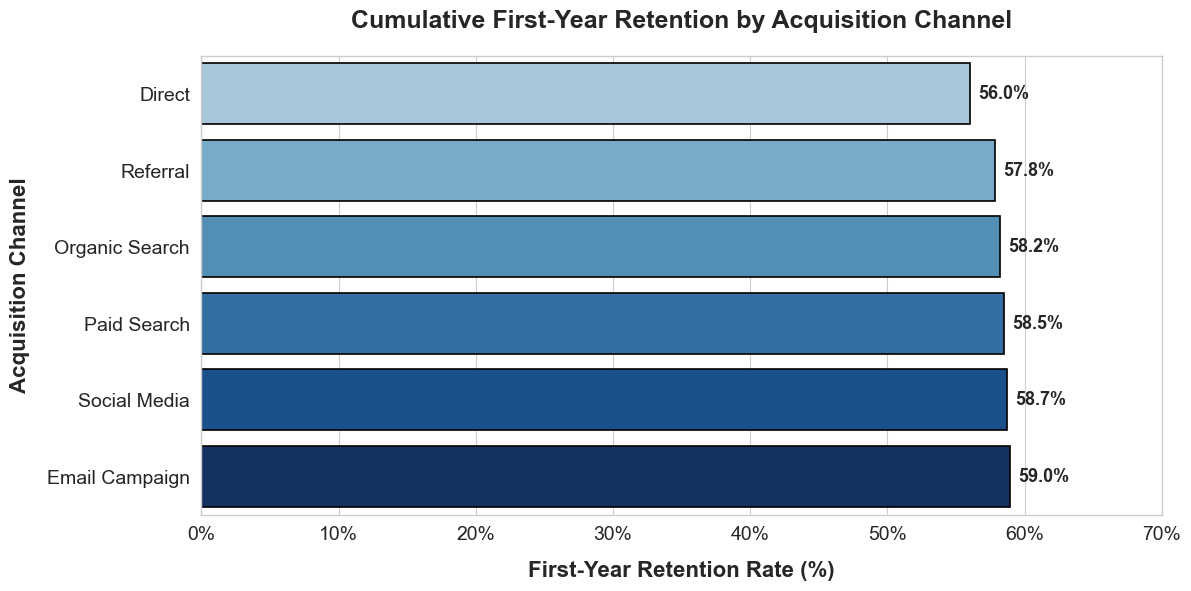

In [41]:
# 1. DATA PREP
# df_cohort in retention heatmap
acquisition_cohorts = df_cohort[df_cohort['MonthsSinceSignup'] == 0][['customer_id', 'order_source']].drop_duplicates(subset=['customer_id'])
first_year_orders = df_cohort[
    (df_cohort['MonthsSinceSignup'] > 0) & 
    (df_cohort['MonthsSinceSignup'] <= 12)
]
retained_customers = first_year_orders['customer_id'].unique()
acquisition_cohorts['retained_year_1'] = acquisition_cohorts['customer_id'].isin(retained_customers).astype(int)

retention_df = acquisition_cohorts.groupby('order_source').agg(
    starting_count=('customer_id', 'nunique'),
    retained_count=('retained_year_1', 'sum')
).reset_index()
retention_df['retention_rate_%'] = (retention_df['retained_count'] / retention_df['starting_count']) * 100
retention_df['order_source'] = retention_df['order_source'].str.replace('_', ' ').str.title()
retention_df = retention_df.sort_values('retention_rate_%', ascending=True)

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))

blue_palette = ['#08306B', '#08519C', '#2171B5', '#4292C6', '#6BAED6', '#9ECAE1'][::-1]

sns.barplot(
    data=retention_df,
    x='retention_rate_%',
    y='order_source',
    hue='order_source', 
    palette=blue_palette,
    edgecolor='black',
    linewidth=1.2,
    alpha=1.0, 
    legend=False,
    ax=ax
)

ax.set_title('Cumulative First-Year Retention by Acquisition Channel', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('First-Year Retention Rate (%)', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Acquisition Channel', fontweight='bold', fontsize=16, labelpad=12)

# DATA LABELS
for p in ax.patches:
    width = p.get_width()
    if width > 0: 
        ax.annotate(f'{width:.1f}%',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(6, 0),
                    textcoords='offset points',
                    fontweight='bold', fontsize=13)

ax.set_xlim(0, 70)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70])

# FORMAT AXES
ax.xaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax.tick_params(axis='both', which='major', labelsize=14)
# plt.setp(ax.get_yticklabels())

plt.tight_layout()
plt.show()

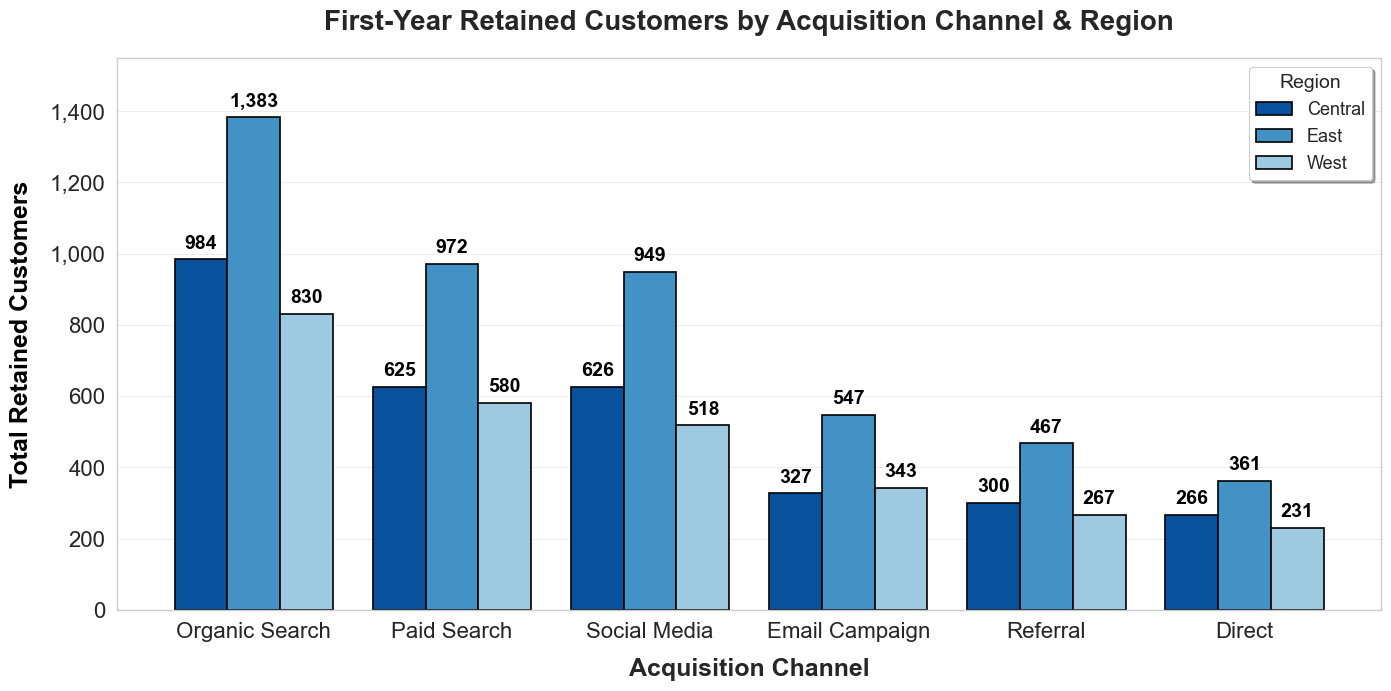

In [42]:
# 1. DATA PREP
df_geo = pd.merge(
    customers[['customer_id', 'zip', 'signup_date', 'acquisition_channel']], 
    geography[['zip', 'region']], 
    on='zip', 
    how='left'
)

df_geo['signup_date'] = pd.to_datetime(df_geo['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

df_chain = pd.merge(
    orders[['order_id', 'customer_id', 'order_date']],
    df_geo,
    on='customer_id',
    how='inner'
)

df_chain['days_since_signup'] = (df_chain['order_date'] - df_chain['signup_date']).dt.days
first_year_orders = df_chain[(df_chain['days_since_signup'] >= 0) & (df_chain['days_since_signup'] <= 365)]
cust_order_counts = first_year_orders.groupby('customer_id').size().reset_index(name='order_count')

retained_custs = cust_order_counts[cust_order_counts['order_count'] > 1][['customer_id']].copy()
retained_custs['is_retained'] = 1

df_retention = pd.merge(df_geo, retained_custs, on='customer_id', how='left')
df_retention['is_retained'] = df_retention['is_retained'].fillna(0)
df_retention['acquisition_channel'] = df_retention['acquisition_channel'].str.replace('_', ' ').str.title()

retention_stats = df_retention.groupby(['acquisition_channel', 'region'], observed=False)['is_retained'].sum().reset_index()

pivot_df = retention_stats.pivot(index='acquisition_channel', columns='region', values='is_retained').fillna(0)
pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns=['Total'])


# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(14, 7))

labels = pivot_df.index.tolist()
x = np.arange(len(labels))
regions = pivot_df.columns.tolist()
n_regions = len(regions)

width = 0.8 / n_regions 
colors = ['#08519C', '#4292C6', '#9ECAE1']

# GROUPED BARS
rects_list = []
for i, region in enumerate(regions):
    offset = x + (i - n_regions/2 + 0.5) * width
    rects = ax1.bar(
        offset, 
        pivot_df[region], 
        width, 
        label=region, 
        color=colors[i % len(colors)], 
        edgecolor='black', 
        linewidth=1.2,
        alpha=1.0
    )
    rects_list.append(rects)

# FORMATTING Y-AXIS
ax1.set_ylabel('Total Retained Customers', 
               fontweight='bold', fontsize=18, color='black', labelpad=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, loc: "{:,}".format(int(val))))
ax1.set_ylim(0, 1550)
ax1.tick_params(axis='y', labelsize=16)

# FORMATTING X-AXIS
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=16)
ax1.set_xlabel('Acquisition Channel', fontweight='bold', fontsize=18, labelpad=12)

# DATA LABELS
for rects in rects_list:
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax1.annotate(f'{int(height):,}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold', color='black', fontsize=14)

# CLEANUP & TITLE
ax1.set_title('First-Year Retained Customers by Acquisition Channel & Region', 
              fontsize=20, fontweight='bold', pad=20)
ax1.grid(True, axis='y', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)
ax1.grid(False, axis='x')

# LEGEND
ax1.legend(title="Region", title_fontsize='14', loc='upper right', frameon=True, fontsize=13, shadow=True)

plt.tight_layout()
plt.show()

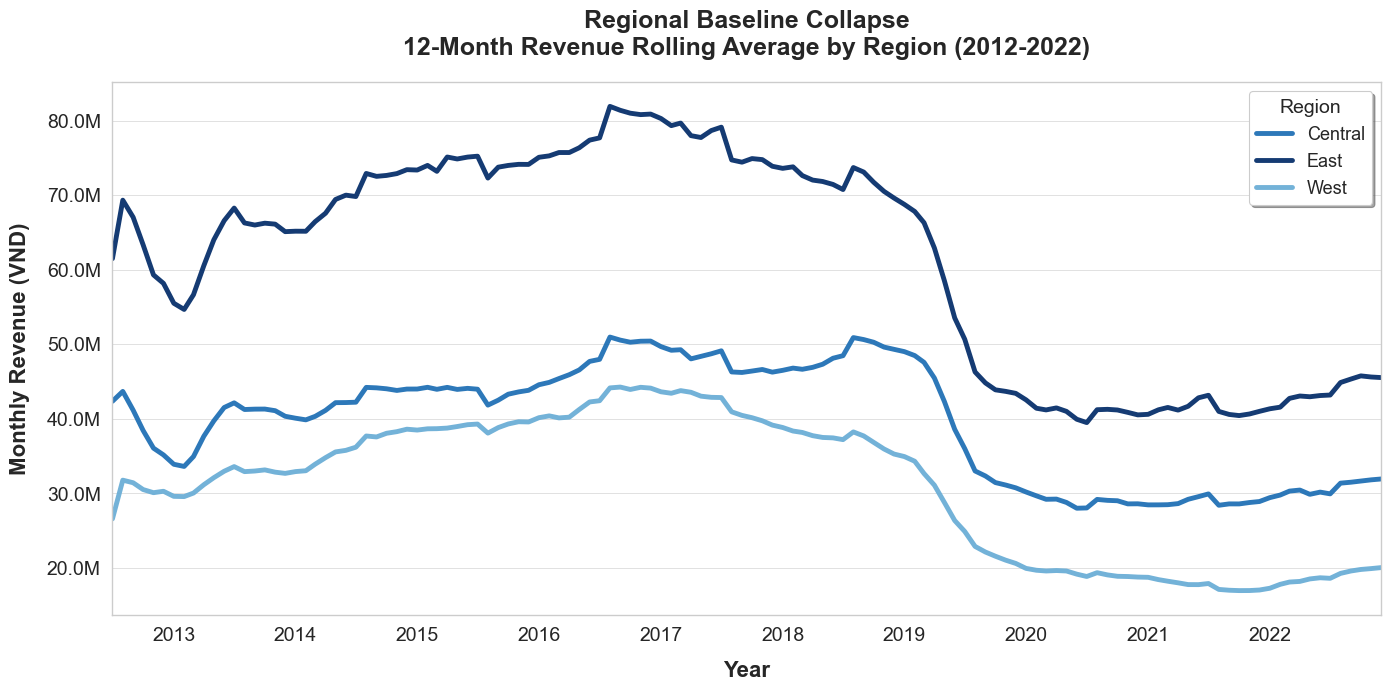

In [43]:
# 1. PREP
df_merged = pd.merge(order_items, orders, on='order_id', how='inner')
df_merged = pd.merge(df_merged, geography, on='zip', how='left')
df_merged['item_revenue'] = df_merged['quantity'] * df_merged['unit_price']
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['month_year'] = df_merged['order_date'].dt.to_period('M').dt.to_timestamp()

monthly_region_rev = df_merged.groupby(['month_year', 'region'], observed=False)['item_revenue'].sum().reset_index()
monthly_region_rev = monthly_region_rev.sort_values(by=['region', 'month_year'])

# 12-Month Moving Average
monthly_region_rev['12M_MA'] = monthly_region_rev.groupby('region')['item_revenue'].transform(
    lambda x: x.rolling(window=12, min_periods=1).mean()
)

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7))

colors = {'East': '#08306B', 'Central': '#2171B5', 'West': '#6BAED6'}
regions = monthly_region_rev['region'].unique()

# MOVING AVG LINE
for region in regions:
    region_data = monthly_region_rev[monthly_region_rev['region'] == region]
    color = colors.get(region, '#333333')
    
    ax.plot(region_data['month_year'], region_data['12M_MA'], 
            label=f"{region}", color=color, linewidth=3.5, alpha=0.95)

# FORMATTING TITLE & AXES
ax.set_title('Regional Baseline Collapse\n12-Month Revenue Rolling Average by Region (2012-2022)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Monthly Revenue (VND)', fontweight='bold', fontsize=16, labelpad=12)

def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
ax.tick_params(axis='y', labelsize=14)

# FORMATTING X-AXIS
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=14, rotation=0)

min_date = monthly_region_rev['month_year'].min()
max_date = monthly_region_rev['month_year'].max()
ax.set_xlim(min_date, max_date)

# CLEANUP & LEGEND
ax.grid(True, axis='y', color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.7)
ax.grid(False, axis='x')

ax.legend(title="Region", title_fontsize='14', loc='upper right', frameon=True, fontsize=13, shadow=True)

plt.tight_layout()
plt.show()

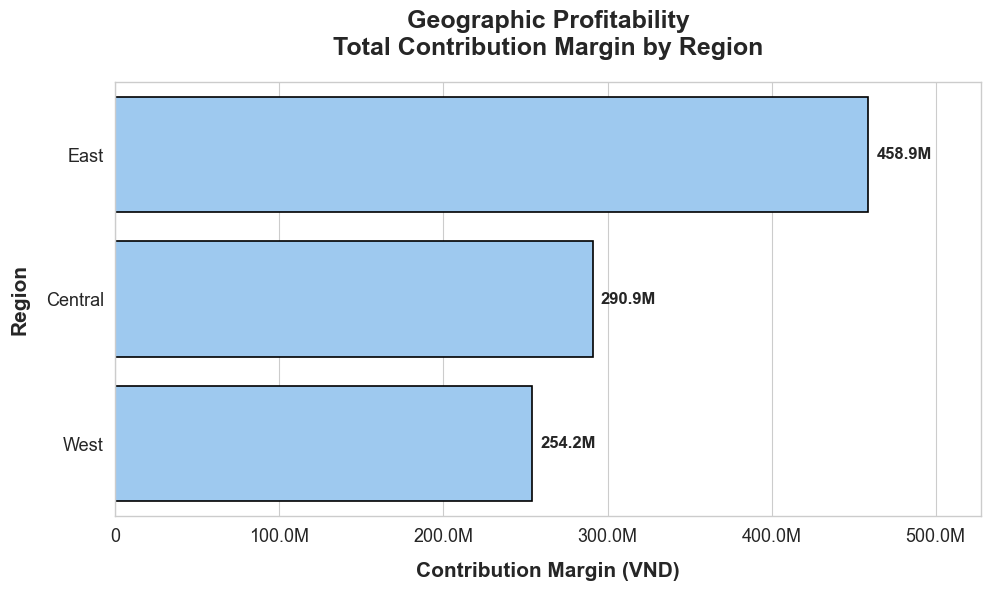

In [44]:
# 1. DATA PREP
# REVENUE
revenue_df = payments.groupby('order_id')['payment_value'].sum().reset_index(name='Revenue')

# COGS
items_with_cogs = pd.merge(order_items[['order_id', 'product_id', 'quantity']], 
                           products[['product_id', 'cogs']], 
                           on='product_id', how='left')
items_with_cogs['total_cogs'] = items_with_cogs['quantity'] * items_with_cogs['cogs']
cogs_df = items_with_cogs.groupby('order_id')['total_cogs'].sum().reset_index(name='COGS')

# SHIPPING FEES
shipping_df = shipments.groupby('order_id')['shipping_fee'].sum().reset_index(name='Shipping_Fee')

# REFUNDS
refunds_df = returns.groupby('order_id')['refund_amount'].sum().reset_index(name='Refund_Amount')

# GEOGRAPHY
orders_geo = pd.merge(orders[['order_id', 'zip']], geography[['zip', 'region']], on='zip', how='inner')

# MERGE
profit_df = orders_geo.merge(revenue_df, on='order_id', how='left') \
                      .merge(cogs_df, on='order_id', how='left') \
                      .merge(shipping_df, on='order_id', how='left') \
                      .merge(refunds_df, on='order_id', how='left')

profit_df = profit_df.fillna(0)

# CONTRIBUTION MARGIN
profit_df['Contribution_Margin'] = (
    profit_df['Revenue'] - 
    profit_df['COGS'] - 
    profit_df['Shipping_Fee'] - 
    profit_df['Refund_Amount']
)

# AGGREGATE BY REGION
regional_profit = profit_df.groupby('region')['Contribution_Margin'].sum().reset_index()
regional_profit = regional_profit.sort_values(by='Contribution_Margin', ascending=False)


# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=regional_profit,
    x='Contribution_Margin',
    y='region',
    color='#91CAFC',
    edgecolor='black',
    linewidth=1.2,
    alpha=1.0,
    ax=ax
)

# FORMATTING TITLE & AXES
ax.set_title('Geographic Profitability\nTotal Contribution Margin by Region', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Contribution Margin (VND)', fontweight='bold', fontsize=15, labelpad=12)
ax.set_ylabel('Region', fontweight='bold', fontsize=15, labelpad=12)

# FORMATTING X-AXIS
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
ax.tick_params(axis='both', which='major', labelsize=13)
# plt.setp(ax.get_yticklabels())

# DATA LABELS
for p in ax.patches:
    width = p.get_width()
    if width > 0: 
        ax.annotate(currency_formatter(width, None),
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(6, 0),
                    textcoords='offset points',
                    fontweight='bold', fontsize=12)

ax.set_xlim(0, regional_profit['Contribution_Margin'].max() * 1.15)

plt.tight_layout()
plt.show()

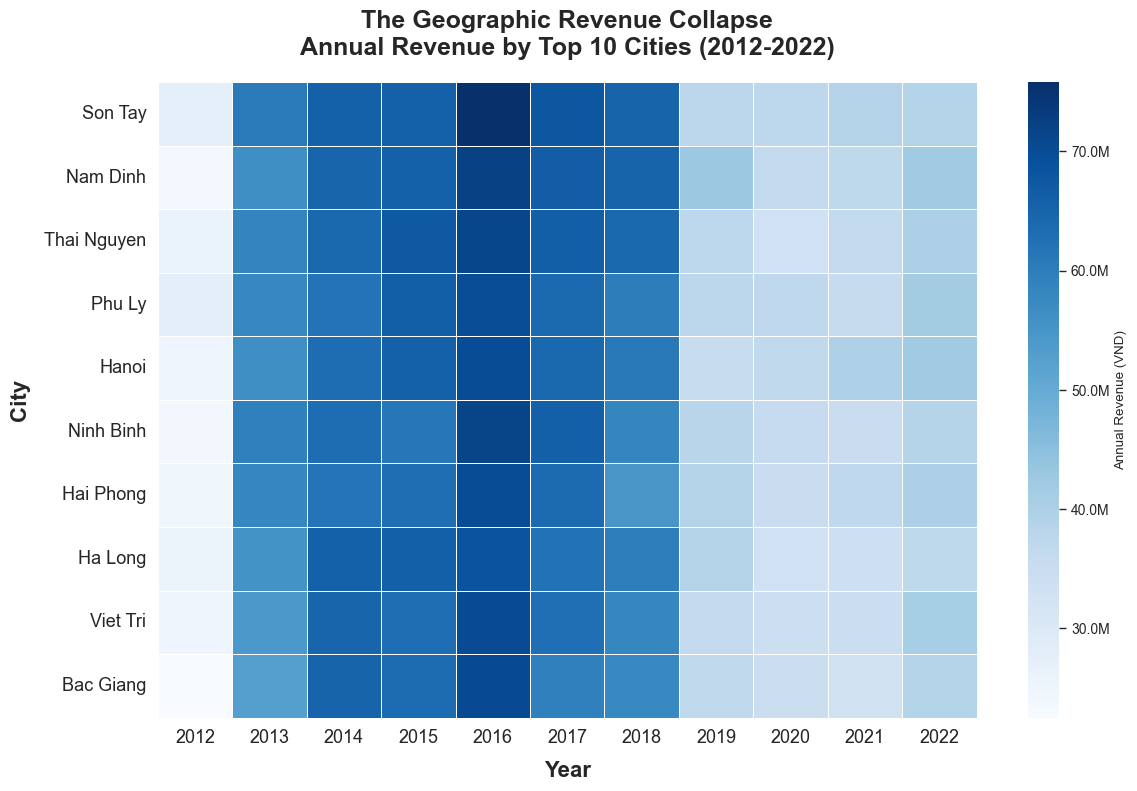

In [45]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price']

df_merged = pd.merge(
    order_items[['order_id', 'item_revenue']], 
    orders[['order_id', 'order_date', 'zip']], 
    on='order_id', 
    how='inner'
)

df_merged = pd.merge(
    df_merged, 
    geography[['zip', 'city']], 
    on='zip', 
    how='inner'
)

df_merged['order_year'] = df_merged['order_date'].dt.year


city_yearly_rev = df_merged.groupby(['city', 'order_year'])['item_revenue'].sum().reset_index()

heatmap_data = city_yearly_rev.pivot(index='city', columns='order_year', values='item_revenue').fillna(0)
heatmap_data['Total_Rev'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values(by='Total_Rev', ascending=False)
heatmap_data = heatmap_data.drop(columns=['Total_Rev'])
heatmap_data = heatmap_data.head(10)

# 3. VISUALIZATION: THE COLLAPSE HEATMAP
sns.set_theme(style="white", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 8))

cmap = sns.color_palette("Blues", as_cmap=True)
sns.heatmap(
    heatmap_data, 
    cmap=cmap, 
    linewidths=0.5,
    linecolor='white', 
    annot=False,
    cbar_kws={'label': 'Annual Revenue (VND)'},
    ax=ax
)

# FORMATTING TITLE & AXES
ax.set_title('The Geographic Revenue Collapse\nAnnual Revenue by Top 10 Cities (2012-2022)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontweight='bold', fontsize=16, labelpad=10)
ax.set_ylabel('City', fontweight='bold', fontsize=16, labelpad=10)

# FORMATTING Y-AXIS
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=13)
plt.setp(ax.get_xticklabels(), fontsize=13)

# COLORBAR
cbar = ax.collections[0].colorbar
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17472\3857585860.py:3: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('order_items.csv')


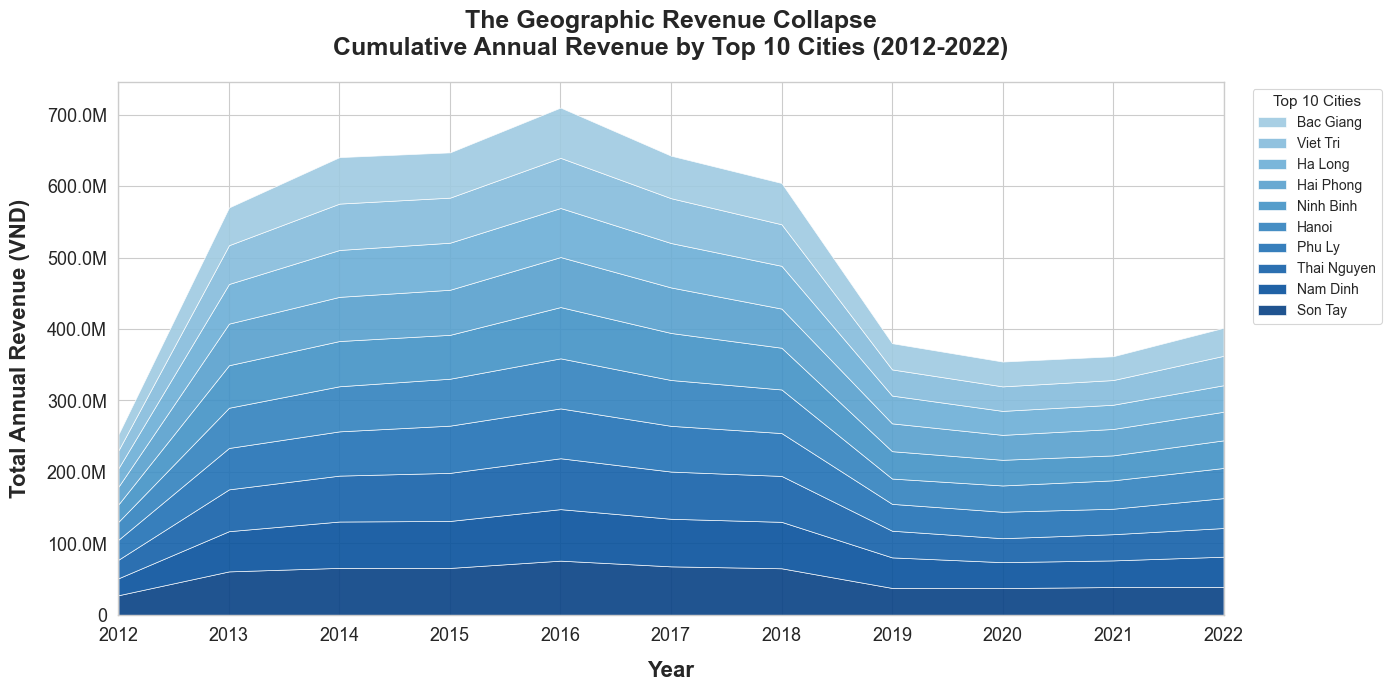

In [46]:
# 1. DATA PREP
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
geography = pd.read_csv('geography.csv')

# REVENUE
orders['order_date'] = pd.to_datetime(orders['order_date'])
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price']

df_merged = pd.merge(order_items[['order_id', 'item_revenue']], 
                     orders[['order_id', 'order_date', 'zip']], on='order_id', how='inner')
df_merged = pd.merge(df_merged, geography[['zip', 'city']], on='zip', how='inner')

# AGGREGATE
df_merged['order_year'] = df_merged['order_date'].dt.year
city_yearly_rev = df_merged.groupby(['order_year', 'city'])['item_revenue'].sum().reset_index()

area_data = city_yearly_rev.pivot(index='order_year', columns='city', values='item_revenue').fillna(0)

city_totals = area_data.sum().sort_values(ascending=False)
top_10_cities = city_totals.head(10).index

area_data = area_data[top_10_cities]

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette("Blues_r", n_colors=15)

# STACKED AREA
ax.stackplot(area_data.index, area_data.T, labels=area_data.columns, 
             colors=colors, alpha=0.9, edgecolor='white', linewidth=0.5)

# FORMATTING TITLE & AXES
ax.set_title('The Geographic Revenue Collapse\nCumulative Annual Revenue by Top 10 Cities (2012-2022)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Total Annual Revenue (VND)', fontweight='bold', fontsize=16, labelpad=12)

# FORMATTING Y-AXIS
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
ax.tick_params(axis='y', labelsize=13)

# X-AXIS
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.tick_params(axis='x', labelsize=13)
ax.set_xlim(area_data.index.min(), area_data.index.max())

# CLEANUP & LEGEND
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), title="Top 10 Cities", 
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

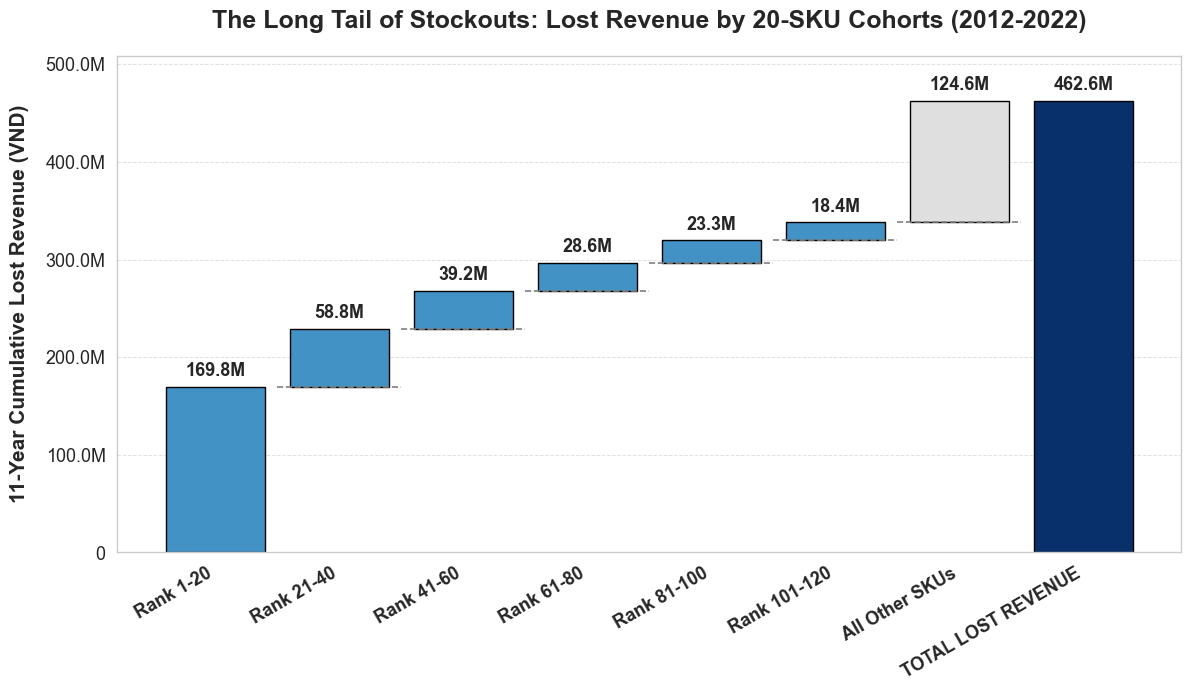

In [47]:
# 1. DATA PREP
inventory['active_days'] = 30 - inventory['stockout_days']
inventory['active_days'] = inventory['active_days'].replace(0, 1)
inventory['daily_velocity'] = inventory['units_sold'] / inventory['active_days']
inventory['estimated_lost_units'] = inventory['daily_velocity'] * inventory['stockout_days']

# MERGE
inv_prod = pd.merge(inventory, products[['product_id', 'price']], on='product_id', how='inner')
inv_prod['lost_revenue'] = inv_prod['estimated_lost_units'] * inv_prod['price']

# 2. BUCKET DATA PER 20 SKUs
sku_lost_rev = inv_prod.groupby('product_id')['lost_revenue'].sum().sort_values(ascending=False).reset_index()
sku_lost_rev['Rank'] = sku_lost_rev.index + 1

bucket_size = 20
max_buckets_to_show = 6

def assign_bucket(rank):
    bucket_num = int(np.ceil(rank / bucket_size))
    if bucket_num <= max_buckets_to_show:
        start = (bucket_num - 1) * bucket_size + 1
        end = bucket_num * bucket_size
        return f"Rank {start}-{end}"
    else:
        return "All Other SKUs"

sku_lost_rev['Bucket_Label'] = sku_lost_rev['Rank'].apply(assign_bucket)


bucket_summary = sku_lost_rev.groupby('Bucket_Label')['lost_revenue'].sum().reset_index()
sort_dict = {assign_bucket(i * bucket_size): i for i in range(1, max_buckets_to_show + 1)}
sort_dict["All Other SKUs"] = max_buckets_to_show + 1
bucket_summary['sort_key'] = bucket_summary['Bucket_Label'].map(sort_dict)
bucket_summary = bucket_summary.sort_values('sort_key')

labels = list(bucket_summary['Bucket_Label']) + ['TOTAL LOST REVENUE']
values = list(bucket_summary['lost_revenue'])
values.append(sum(values))

starts = [0]
for i in range(1, len(values) - 1):
    starts.append(starts[i-1] + values[i-1])
starts.append(0)

# 3. VISUALIZATION

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#4292C6'] * max_buckets_to_show + ["#DFDFDF", '#08306B']
bars = ax.bar(labels, values, bottom=starts, color=colors, edgecolor='black', linewidth=1, alpha=1.0)

for i in range(1, len(values) - 1):
    ax.plot([i-0.5, i+0.5], [starts[i], starts[i]], color='gray', linestyle='--', linewidth=1.2)

# FORMATTING TITLE & AXES
ax.set_title('The Long Tail of Stockouts: Lost Revenue by 20-SKU Cohorts (2012-2022)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('11-Year Cumulative Lost Revenue (VND)', fontweight='bold', fontsize=15, labelpad=12)

# FORMATTING Y-AXIS
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
ax.tick_params(axis='y', labelsize=13)

# FORMATTING X-AXIS
plt.xticks(rotation=30, ha='right', fontsize=13, fontweight='bold')

# DATA LABELS
for b in bars:
    height = b.get_height()
    bottom = b.get_y()
    ax.annotate(currency_formatter(height, None),
                (b.get_x() + b.get_width()/2., bottom + height),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontweight='bold', fontsize=13)

ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.7, alpha=0.7)
ax.grid(False, axis='x')

ax.set_ylim(0, max(starts[-2] + values[-2], values[-1]) * 1.1)

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17472\3036088866.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  forecast_df['seasonality_index'].fillna(1.0, inplace=True)


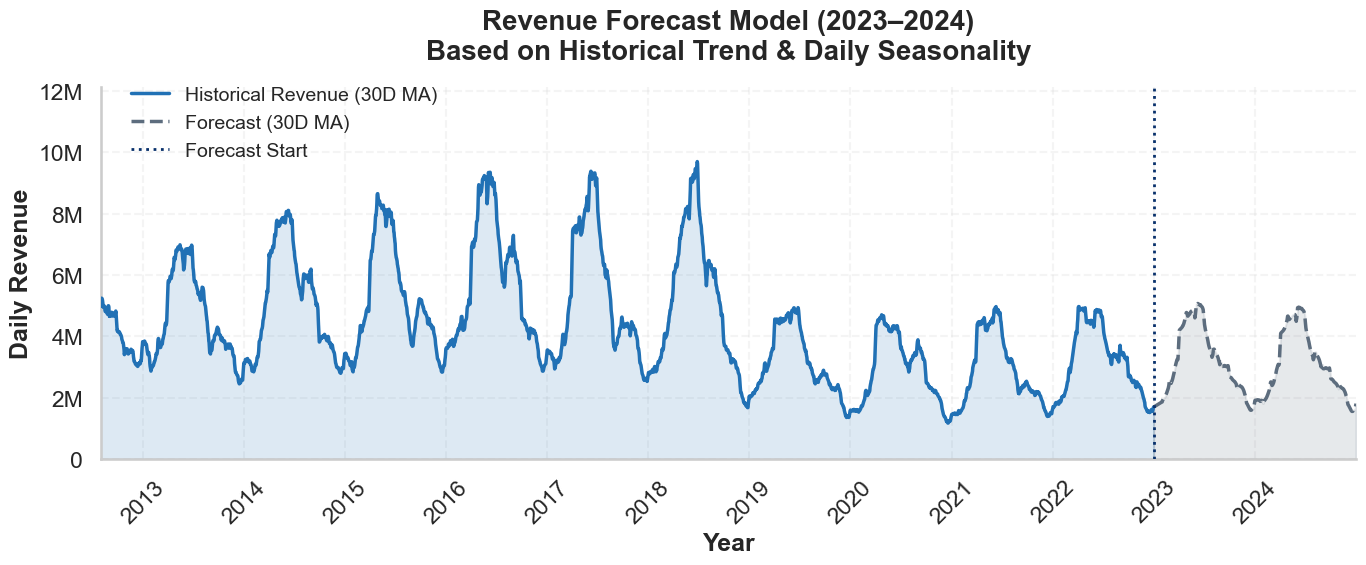

In [48]:
# 1. LOAD & PREP DATA
df = pd.merge(order_items, orders, on='order_id')
df['revenue'] = df['quantity'] * df['unit_price']
df['order_date'] = pd.to_datetime(df['order_date'])

# AGGREGATE
daily_hist = df.groupby(df['order_date'].dt.date)['revenue'].sum().reset_index()
daily_hist['order_date'] = pd.to_datetime(daily_hist['order_date'])
daily_hist['year'] = daily_hist['order_date'].dt.year
daily_hist['month_day'] = daily_hist['order_date'].dt.strftime('%m-%d')

# 2. CALCULATE MODEL PARAMETERS
# P1: AVG YoY GROWTH RATE (2013-2022)
yearly_rev = daily_hist[(daily_hist['year'] >= 2013) & (daily_hist['year'] <= 2022)].groupby('year')['revenue'].sum()
yoy_growth = yearly_rev.pct_change().mean() 

# P2: SEASONALITY INDEX/DAY
day_avg = daily_hist.groupby('month_day')['revenue'].mean().reset_index(name='day_specific_avg')
global_daily_avg = daily_hist['revenue'].mean()
day_avg['seasonality_index'] = day_avg['day_specific_avg'] / global_daily_avg

# P3: 2022 BASE LEVEL
avg_rev_2022 = daily_hist[daily_hist['year'] == 2022]['revenue'].mean()

# 3. GENERATE FORECAST
future_dates = pd.date_range(start='2023-01-01', end='2024-12-31')
forecast_df = pd.DataFrame({'order_date': future_dates})
forecast_df['year'] = forecast_df['order_date'].dt.year
forecast_df['month_day'] = forecast_df['order_date'].dt.strftime('%m-%d')

# MAP INDEX
forecast_df = forecast_df.merge(day_avg[['month_day', 'seasonality_index']], on='month_day', how='left')
forecast_df['seasonality_index'].fillna(1.0, inplace=True) 

def apply_forecast_formula(row):
    t = row['year'] - 2022 
    trend_multiplier = (1 + yoy_growth) ** t
    return avg_rev_2022 * trend_multiplier * row['seasonality_index']

forecast_df['forecast_revenue'] = forecast_df.apply(apply_forecast_formula, axis=1)

# 4. VISUALIZATION
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 6))

hist_rolling = daily_hist.set_index('order_date')['revenue'].rolling(window=30).mean().dropna()
forecast_rolling = forecast_df.set_index('order_date')['forecast_revenue'].rolling(window=30).mean().dropna()

last_hist_date = hist_rolling.index[-1]
last_hist_value = hist_rolling.values[-1]

forecast_index_fixed = forecast_rolling.index.insert(0, last_hist_date)
forecast_values_fixed = np.insert(forecast_rolling.values, 0, last_hist_value)

# HISTORY LINE
sns.lineplot(
    x=hist_rolling.index, 
    y=hist_rolling.values, 
    color='#2171B5', 
    linewidth=2.5, 
    label='Historical Revenue (30D MA)',
    zorder=3,
    ax=ax
)
ax.fill_between(
    hist_rolling.index, 
    hist_rolling.values, 
    color='#2171B5', 
    alpha=0.15, 
    zorder=2
)

# FORECAST LINE & SHADING
sns.lineplot(
    x=forecast_index_fixed, 
    y=forecast_values_fixed, 
    color='#5D6D7E', 
    linestyle='--', 
    linewidth=2.5, 
    label='Forecast (30D MA)',
    zorder=3,
    ax=ax
)
ax.fill_between(
    forecast_index_fixed, 
    forecast_values_fixed, 
    color='#5D6D7E', 
    alpha=0.15, 
    zorder=2
)

# FORMATTING & CLEANUP
ax.set_title(
    'Revenue Forecast Model (2023–2024)\nBased on Historical Trend & Daily Seasonality', 
    fontsize=20, fontweight='bold', pad=20
)
ax.set_xlabel('Year', fontsize=18, fontweight='bold')
ax.set_ylabel('Daily Revenue', fontsize=18, fontweight='bold')

ax.axvline(pd.to_datetime('2022-12-31'), color='#08306B', linestyle=':', linewidth=2, label='Forecast Start', zorder=4)

# Y-AXIS
def currency_formatter(x, pos):
    if x >= 1e9: return f'{x / 1e9:,.1f}B'
    if x >= 1e6: return f'{x / 1e6:,.0f}M'
    return f'{x:,.0f}'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))

# X-AXIS
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

ax.grid(True, linestyle='--', alpha=0.2, zorder=0)
sns.despine(ax=ax, top=True, right=True)

# LEGEND
ax.legend(
    frameon=False, 
    loc='upper left', 
    bbox_to_anchor=(0.01, 1.05), 
    fontsize=14
)

ax.set_xlim(hist_rolling.index.min(), forecast_index_fixed.max())
max_y_value = max(hist_rolling.max(), forecast_values_fixed.max())
ax.set_ylim(0, max_y_value * 1.25) 

plt.tight_layout()
plt.show()

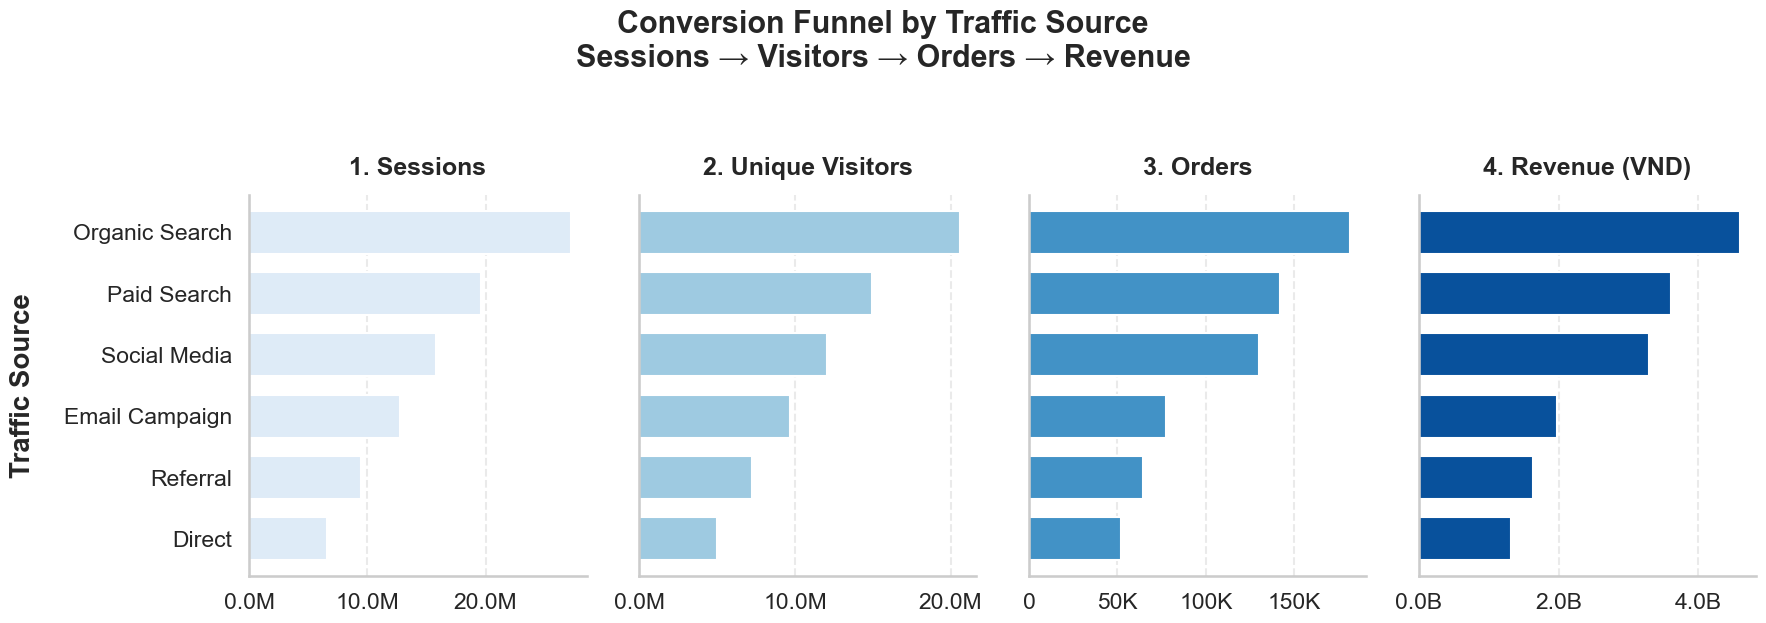

In [49]:
# 1. PREP & ALIGN DATA
df = pd.merge(order_items, orders, on='order_id')
df['revenue'] = df['quantity'] * df['unit_price']
df = df.rename(columns={'order_source': 'traffic_source'})

# TOP OF FUNNEL
top_funnel = web_traffic.groupby('traffic_source').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum')
).reset_index()

# BOTTOM OF FUNNEL
bottom_funnel = df.groupby('traffic_source').agg(
    orders=('order_id', 'nunique'), 
    revenue=('revenue', 'sum')
).reset_index()

# MERGE
funnel_data = pd.merge(top_funnel, bottom_funnel, on='traffic_source', how='left')
funnel_data = funnel_data.fillna(0)

# CLEAN
funnel_data['traffic_source'] = funnel_data['traffic_source'].str.replace('_', ' ').str.title()
funnel_data = funnel_data.set_index('traffic_source')
funnel_data = funnel_data.sort_values(by='sessions', ascending=True)

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
fig.suptitle('Conversion Funnel by Traffic Source\nSessions → Visitors → Orders → Revenue', 
             fontsize=22, fontweight='bold', y=1.05)


metrics = ['sessions', 'unique_visitors', 'orders', 'revenue']
titles = ['1. Sessions', '2. Unique Visitors', '3. Orders', '4. Revenue (VND)']
colors = ['#DEEBF7', '#9ECAE1', '#4292C6', '#08519C']

# 3. PLOT FUNNEL
for i, metric in enumerate(metrics):
    ax = axes[i]
    funnel_data[metric].plot(kind='barh', ax=ax, color=colors[i], width=0.7)
    
    # TITLES
    ax.set_title(titles[i], fontsize=18, fontweight='bold', pad=15)
    ax.set_ylabel('')
    
    # FORMATTING X-AXIS
    if metric in ['sessions', 'unique_visitors']:
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x / 1e6:,.1f}M'))
    elif metric == 'orders':
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x / 1e3:,.0f}K' if x >= 1000 else f'{x:,.0f}'))
    elif metric == 'revenue':
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x / 1e9:,.1f}B'))

    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    ax.grid(False, axis='y')
    sns.despine(ax=ax, top=True, right=True)

axes[0].set_ylabel('Traffic Source', fontsize=20, fontweight='bold', labelpad=20)

# Display the plot
plt.tight_layout()
plt.show()

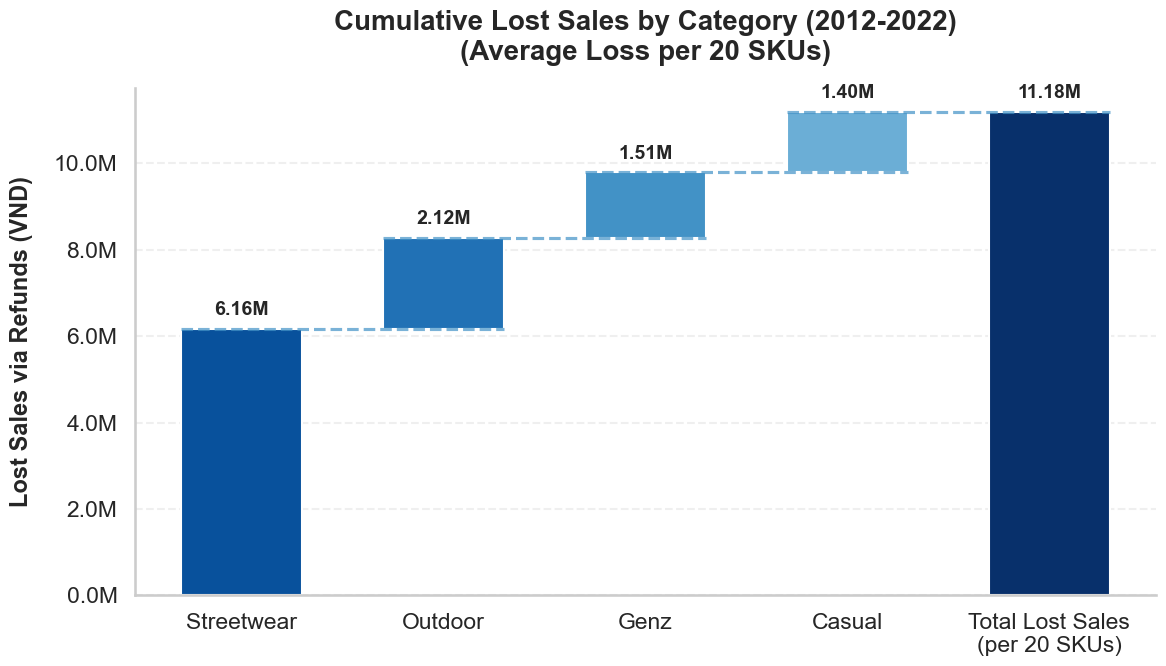

In [50]:
# 1. DATA PREP
df = pd.merge(returns, products[['product_id', 'category']], on='product_id', how='left')
df['category'] = df['category'].str.title()
products['category'] = products['category'].str.title()

# REFUND
category_losses = df.groupby('category')['refund_amount'].sum().reset_index()
category_losses.rename(columns={'refund_amount': 'Total_Loss'}, inplace=True)

# TOTAL SKUs/CAT
category_sku_counts = products.groupby('category')['product_id'].nunique().reset_index()
category_sku_counts.rename(columns={'product_id': 'Total_SKUs'}, inplace=True)

metrics = pd.merge(category_losses, category_sku_counts, on='category', how='right')

target_categories = ['Casual', 'Streetwear', 'Outdoor', 'Genz']
metrics = metrics[metrics['category'].isin(target_categories)].copy()
metrics['Total_Loss'] = metrics['Total_Loss'].fillna(0)

metrics['Loss_Per_20_SKUs'] = (metrics['Total_Loss'] / metrics['Total_SKUs']) * 20
metrics = metrics.sort_values('Loss_Per_20_SKUs', ascending=False)

# 2. CALCULATION
total_loss_20 = metrics['Loss_Per_20_SKUs'].sum()

categories = metrics['category'].tolist() + ['Total Lost Sales\n(per 20 SKUs)']
values = metrics['Loss_Per_20_SKUs'].tolist() + [total_loss_20]

bottoms = [0]
for i in range(len(values) - 2):
    bottoms.append(bottoms[-1] + values[i])
bottoms.append(0) 

# 4. VISUALIZATION
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 7))

palette = ['#08306B', '#08519C', '#2171B5', '#4292C6', '#6BAED6', '#9ECAE1']

step_colors = palette[1:1+len(metrics)] 
bar_colors = step_colors + [palette[0]]

bars = ax.bar(categories, values, bottom=bottoms, color=bar_colors, width=0.6, edgecolor='white', linewidth=1.5)

# TITLE
ax.set_title(
    'Cumulative Lost Sales by Category (2012-2022)\n(Average Loss per 20 SKUs)',
    fontsize=20, fontweight='bold', pad=20
)
ax.set_ylabel('Lost Sales via Refunds (VND)', fontsize=17, fontweight='bold', labelpad=15)

for i in range(1, len(values)):
    prev_top = bottoms[i-1] + values[i-1]
    ax.plot([i-1 - 0.3, i + 0.3], [prev_top, prev_top], color=palette[3], linestyle='--', alpha=0.7)

# LABELS
for i, bar in enumerate(bars):
    y_val = bottoms[i] + values[i]
    val = values[i]
    
    text_label = f"{val/1e6:.2f}M" if val > 0 else "0.00M"
    
    ax.text(bar.get_x() + bar.get_width()/2, y_val + (total_loss_20 * 0.02), 
            text_label, ha='center', va='bottom', fontsize=14, fontweight='bold')

# FORMATTING Y-AXIS
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.grid(False, axis='x')
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

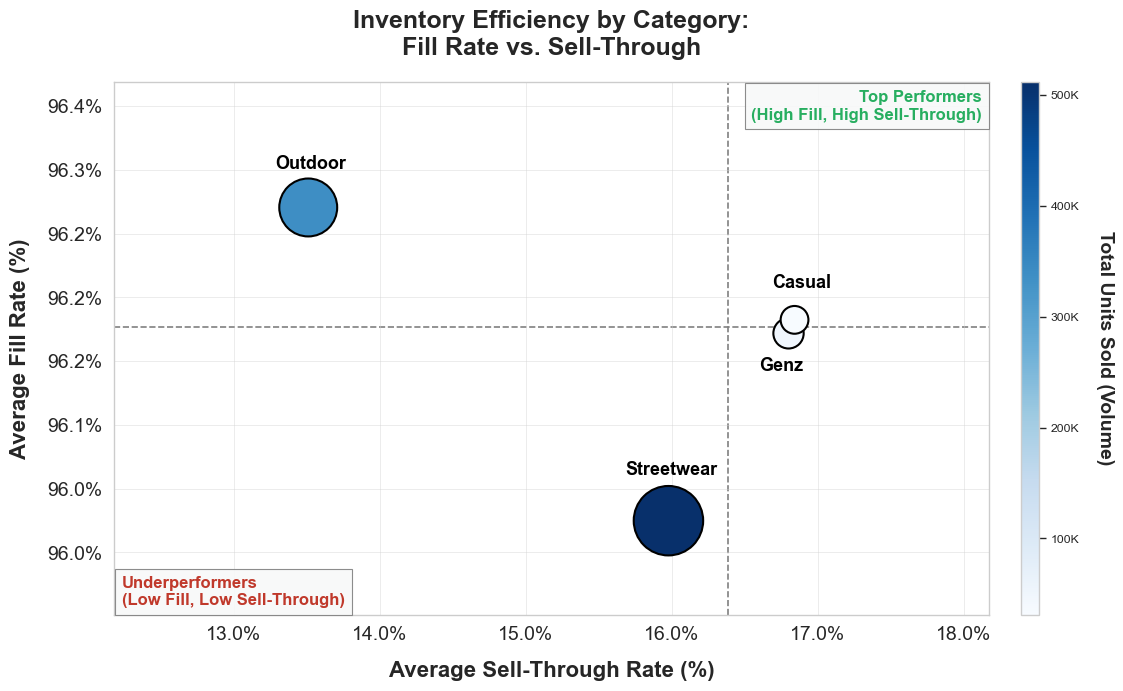

In [51]:
# 1. DATA PREP
inventory['category'] = inventory['category'].str.title()

metrics = inventory.groupby('category').agg(
    Avg_Sell_Through=('sell_through_rate', 'mean'),
    Avg_Fill_Rate=('fill_rate', 'mean'),
    Total_Units_Sold=('units_sold', 'sum')
).reset_index()

metrics['Avg_Sell_Through_%'] = metrics['Avg_Sell_Through'] * 100
metrics['Avg_Fill_Rate_%'] = metrics['Avg_Fill_Rate'] * 100

metrics = metrics.sort_values(by='Total_Units_Sold', ascending=False).reset_index(drop=True)

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper") 
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 7))

scatter = sns.scatterplot(
    data=metrics, 
    x='Avg_Sell_Through_%',
    y='Avg_Fill_Rate_%', 
    size='Total_Units_Sold', 
    sizes=(400, 2500),         
    hue='Total_Units_Sold',       
    palette='Blues',            
    alpha=1.0, 
    edgecolor='black',
    linewidth=1.5,             
    ax=ax
)

# BOUNDING BOX
x_min = metrics['Avg_Sell_Through_%'].min()
x_max = metrics['Avg_Sell_Through_%'].max()
x_range = x_max - x_min

y_min = metrics['Avg_Fill_Rate_%'].min()
y_max = metrics['Avg_Fill_Rate_%'].max()
y_range = y_max - y_min

ax.set_xlim(x_min - (x_range * 0.4), x_max + (x_range * 0.4))
ax.set_ylim(y_min - (y_range * 0.3), y_max + (y_range * 0.4))

# QUADRANT LINES
x_mid = metrics['Avg_Sell_Through_%'].median()
y_mid = metrics['Avg_Fill_Rate_%'].median()
ax.axvline(x_mid, color='grey', linestyle='--', linewidth=1.2, zorder=0)
ax.axhline(y_mid, color='grey', linestyle='--', linewidth=1.2, zorder=0)

ax.grid(True, which='major', color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.6)

# QUADRANT BOXES
bbox_props = dict(boxstyle="square,pad=0.4", fc="#F8F9F9", ec="grey", alpha=0.9)

ax.text(0.992, 0.985, 'Top Performers\n(High Fill, High Sell-Through)', 
        transform=ax.transAxes, ha='right', va='top', color='#27AE60', fontsize=12, fontweight='bold', bbox=bbox_props)
ax.text(0.0094, 0.012, 'Underperformers\n(Low Fill, Low Sell-Through)', 
        transform=ax.transAxes, ha='left', va='bottom', color='#C0392B', fontsize=12, fontweight='bold', bbox=bbox_props)

# Format axes as percentages
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}%"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:.1f}%"))
ax.tick_params(axis='both', which='major', labelsize=14)

# LABEL PLACEMENT
custom_offsets = {
    'Casual': (5, 20),
    'Streetwear': (2, 30),
    'Outdoor': (2, 25),
    'Genz': (-5, -30)
}

for i in range(metrics.shape[0]):
    cat_name = metrics['category'][i]
    offset = custom_offsets.get(cat_name, (0, 30))
    
    ax.annotate(
        cat_name,
        (metrics['Avg_Sell_Through_%'][i], metrics['Avg_Fill_Rate_%'][i]),
        xytext=offset,
        textcoords='offset points',
        ha='center', va='bottom',
        color='black', weight='bold', fontsize=13
    )

# TITLES
ax.set_title('Inventory Efficiency by Category:\nFill Rate vs. Sell-Through', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Average Sell-Through Rate (%)', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Average Fill Rate (%)', fontweight='bold', fontsize=16, labelpad=12)

# COLORBAR
ax.get_legend().remove()
norm = plt.Normalize(metrics['Total_Units_Sold'].min(), metrics['Total_Units_Sold'].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.03, aspect=30)
cbar.set_label('Total Units Sold (Volume)', rotation=270, labelpad=25, fontweight='bold', fontsize=14)

cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x / 1e3:.0f}K" if x < 1e6 else f"{x / 1e6:.1f}M"))

plt.tight_layout()
plt.show()

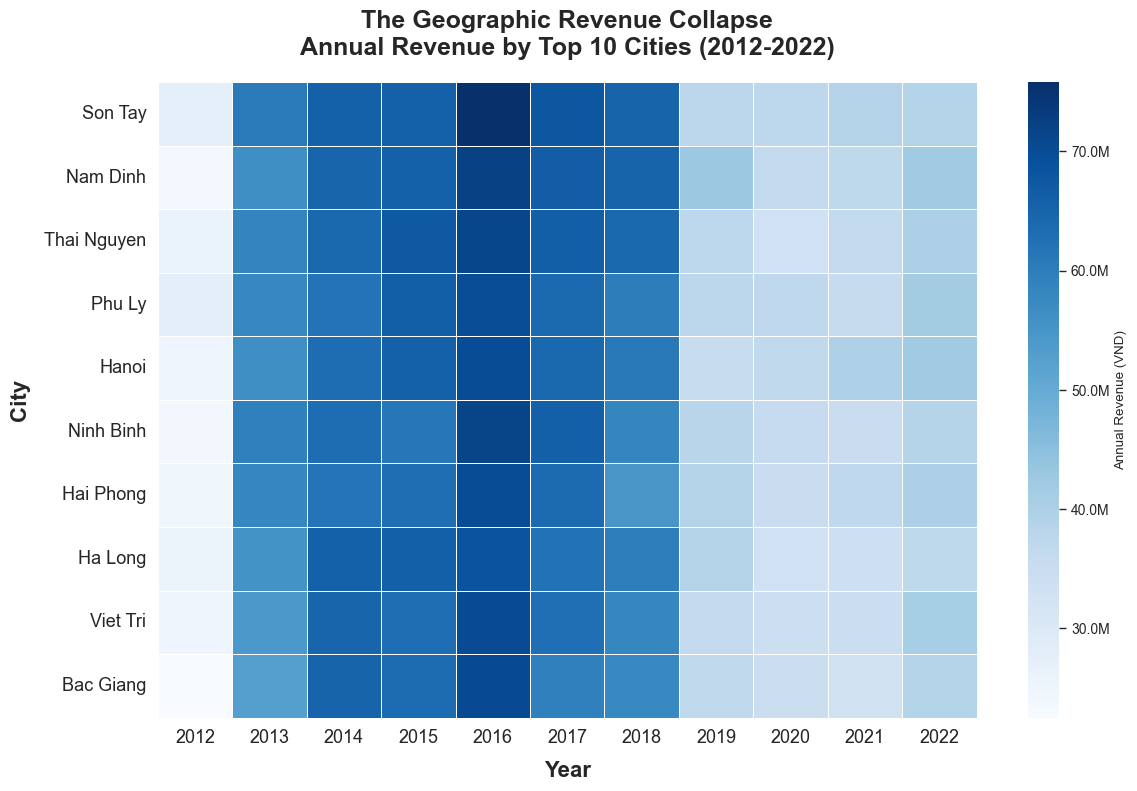

In [52]:
# 1. DATA PREP
orders['order_date'] = pd.to_datetime(orders['order_date'])
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price']

df_merged = pd.merge(
    order_items[['order_id', 'item_revenue']],
    orders[['order_id', 'order_date', 'zip']],
    on='order_id',
    how='inner'
)

df_merged = pd.merge(
    df_merged,
    geography[['zip', 'city']],
    on='zip',
    how='inner'
)

df_merged['order_year'] = df_merged['order_date'].dt.year


city_yearly_rev = df_merged.groupby(['city', 'order_year'])['item_revenue'].sum().reset_index()

heatmap_data = city_yearly_rev.pivot(index='city', columns='order_year', values='item_revenue').fillna(0)
heatmap_data['Total_Rev'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values(by='Total_Rev', ascending=False)
heatmap_data = heatmap_data.drop(columns=['Total_Rev'])
heatmap_data = heatmap_data.head(10)

# 2. VISUALIZATION
sns.set_theme(style="white", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 8))

cmap = sns.color_palette("Blues", as_cmap=True)
sns.heatmap(
    heatmap_data,
    cmap=cmap,
    linewidths=0.5,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Annual Revenue (VND)'},
    ax=ax
)

# FORMATTING TITLE & AXES
ax.set_title('The Geographic Revenue Collapse\nAnnual Revenue by Top 10 Cities (2012-2022)',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontweight='bold', fontsize=16, labelpad=10)
ax.set_ylabel('City', fontweight='bold', fontsize=16, labelpad=10)

# FORMATTING Y-AXIS
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=13)
plt.setp(ax.get_xticklabels(), fontsize=13)

# COLORBAR
cbar = ax.collections[0].colorbar
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

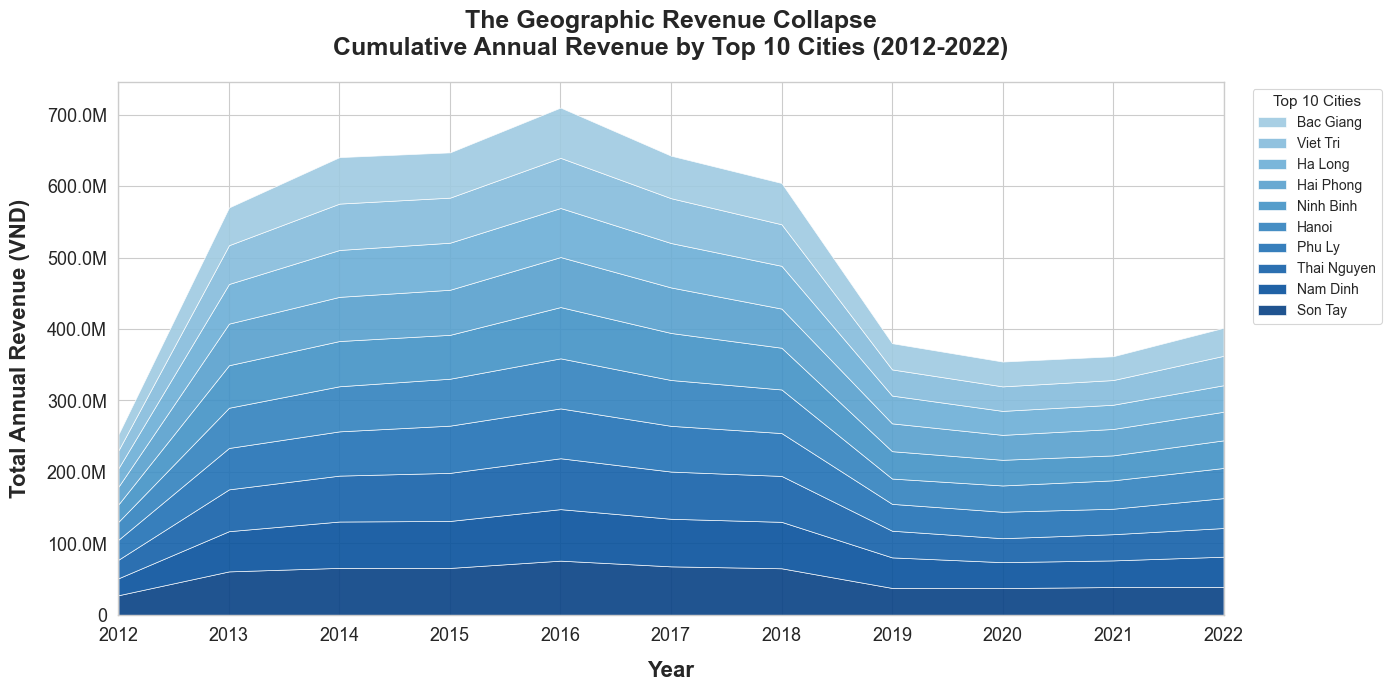

In [53]:
# 1. DATA PREP
orders['order_date'] = pd.to_datetime(orders['order_date'])
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price']

df_merged = pd.merge(order_items[['order_id', 'item_revenue']],
                     orders[['order_id', 'order_date', 'zip']], on='order_id', how='inner')
df_merged = pd.merge(df_merged, geography[['zip', 'city']], on='zip', how='inner')

# AGGREGATE
df_merged['order_year'] = df_merged['order_date'].dt.year
city_yearly_rev = df_merged.groupby(['order_year', 'city'])['item_revenue'].sum().reset_index()

area_data = city_yearly_rev.pivot(index='order_year', columns='city', values='item_revenue').fillna(0)

city_totals = area_data.sum().sort_values(ascending=False)
top_10_cities = city_totals.head(10).index

area_data = area_data[top_10_cities]

# 2. VISUALIZATION
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette("Blues_r", n_colors=15)

# STACKED AREA
ax.stackplot(area_data.index, area_data.T, labels=area_data.columns,
             colors=colors, alpha=0.9, edgecolor='white', linewidth=0.5)

# FORMATTING TITLE & AXES
ax.set_title('The Geographic Revenue Collapse\nCumulative Annual Revenue by Top 10 Cities (2012-2022)',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontweight='bold', fontsize=16, labelpad=12)
ax.set_ylabel('Total Annual Revenue (VND)', fontweight='bold', fontsize=16, labelpad=12)

# FORMATTING Y-AXIS
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    else:
        return f'{x:,.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))
ax.tick_params(axis='y', labelsize=13)

# X-AXIS
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.tick_params(axis='x', labelsize=13)
ax.set_xlim(area_data.index.min(), area_data.index.max())

# CLEANUP & LEGEND
handles, labels = ax.get_legend_handles_labels()
ax.legend(list(reversed(handles)), list(reversed(labels)), title="Top 10 Cities",
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

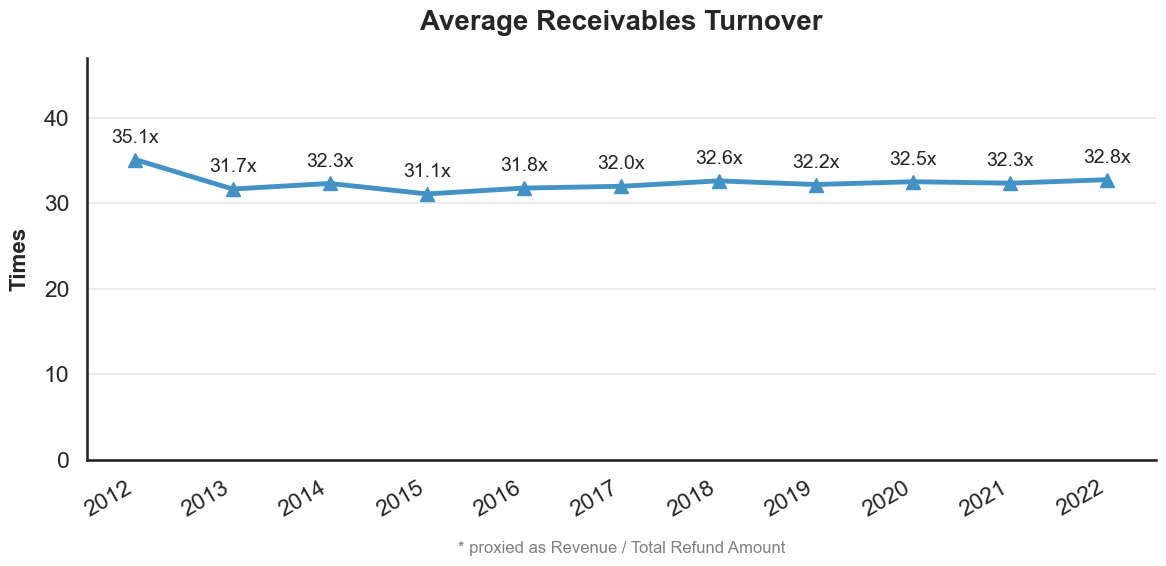

In [54]:
# 1. DATA PREP
sales["year"]            = pd.to_datetime(sales["Date"]).dt.year
returns["year"]          = pd.to_datetime(returns["return_date"]).dt.year
revenue = sales.groupby("year")["Revenue"].sum()
refunds = returns.groupby("year")["refund_amount"].sum()

metrics = pd.DataFrame({
    'Revenue': revenue,
    'Refunds': refunds
}).reset_index()

# AVG RECEIVABLES TURNOVER (ART)
metrics['ART'] = metrics['Revenue'] / metrics['Refunds']

metrics = metrics[(metrics['year'] >= 2012) & (metrics['year'] <= 2022)].copy()
metrics.sort_values('year', inplace=True)

years = metrics['year'].astype(str).tolist()
values = metrics['ART'].tolist()

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))

line_color = '#4292C6'
ax.plot(years, values, color=line_color, linewidth=3.5, marker='^', markersize=10, zorder=3)

# TITLE & LABELS
ax.set_title('Average Receivables Turnover', fontsize=20, fontweight='bold', pad=20)
ax.set_ylabel('Times', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('* proxied as Revenue / Total Refund Amount', fontsize=12, color='gray', labelpad=15)

# DATA LABELS
for i, val in enumerate(values):
    ax.text(i, val + 1.5, f"{val:.1f}x", ha='center', va='bottom', fontsize=14)

# FORMATTING Y-AXIS & GRID
ax.set_ylim(0, 47)
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
# ax.grid(True, axis='x', linestyle='-', alpha=0.4, zorder=0)
sns.despine(ax=ax, top=True, right=True)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

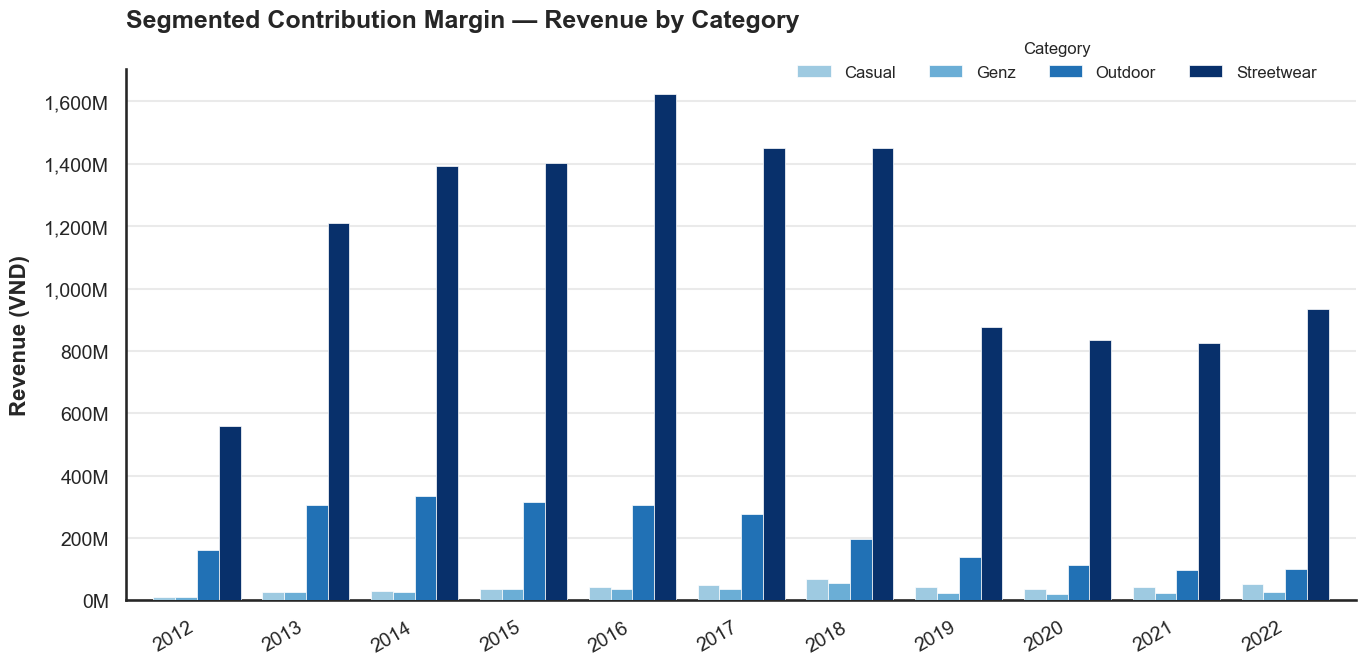

In [55]:
# 1. DATA PREP
oi = order_items.merge(products[["product_id", "category", "cogs"]], on="product_id", how="left")
oi["rev"] = oi["unit_price"] * oi["quantity"] - oi["discount_amount"]
oi["vc"]  = oi["cogs"] * oi["quantity"]
oi["cm"]  = oi["rev"] - oi["vc"]

oi = oi.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
oi["year"] = pd.to_datetime(oi["order_date"]).dt.year

# AGGREGATE
cm_df = (
    oi.groupby(["year", "category"])
    .agg(Revenue=("rev", "sum"), CM=("cm", "sum"))
    .reset_index()
    .assign(CM_pct=lambda d: d["CM"] / d["Revenue"] * 100)
)
cm_df = cm_df[(cm_df["year"] >= 2012) & (cm_df["year"] <= 2022)].copy()
cm_pivot_rev = cm_df.pivot(index="year", columns="category", values="Revenue") / 1e6
cm_pivot_pct = cm_df.pivot(index="year", columns="category", values="CM_pct")

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7))

cat_colors = ['#9ECAE1', '#6BAED6', '#2171B5', '#08306B']

# Render the grouped bar chart natively through Pandas
cm_pivot_rev.plot(
    kind='bar',
    color=cat_colors,
    width=0.8,
    edgecolor='white',
    linewidth=0.5,
    ax=ax,
    zorder=3
)

# TITLE & LABELS
ax.set_title(
    'Segmented Contribution Margin — Revenue by Category',
    fontsize=18, fontweight='bold', loc='left', pad=30
)
ax.set_ylabel('Revenue (VND)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('')

# FORMATTING Y-AXIS
formatter = FuncFormatter(lambda x, pos: f'{int(x):,}M' if x != 0 else '0M')
ax.yaxis.set_major_formatter(formatter)

# LEGEND LAYOUT
ax.legend(
    title='Category',
    title_fontsize=12,
    fontsize=12,
    loc='upper right',
    bbox_to_anchor=(0.98, 1.08),
    ncol=4,
    frameon=False
)

# GRID & DESPINE
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
# ax.grid(True, axis='x', linestyle='-', alpha=0.4, zorder=0)
sns.despine(ax=ax, top=True, right=True)

# TICK FORMATTING
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

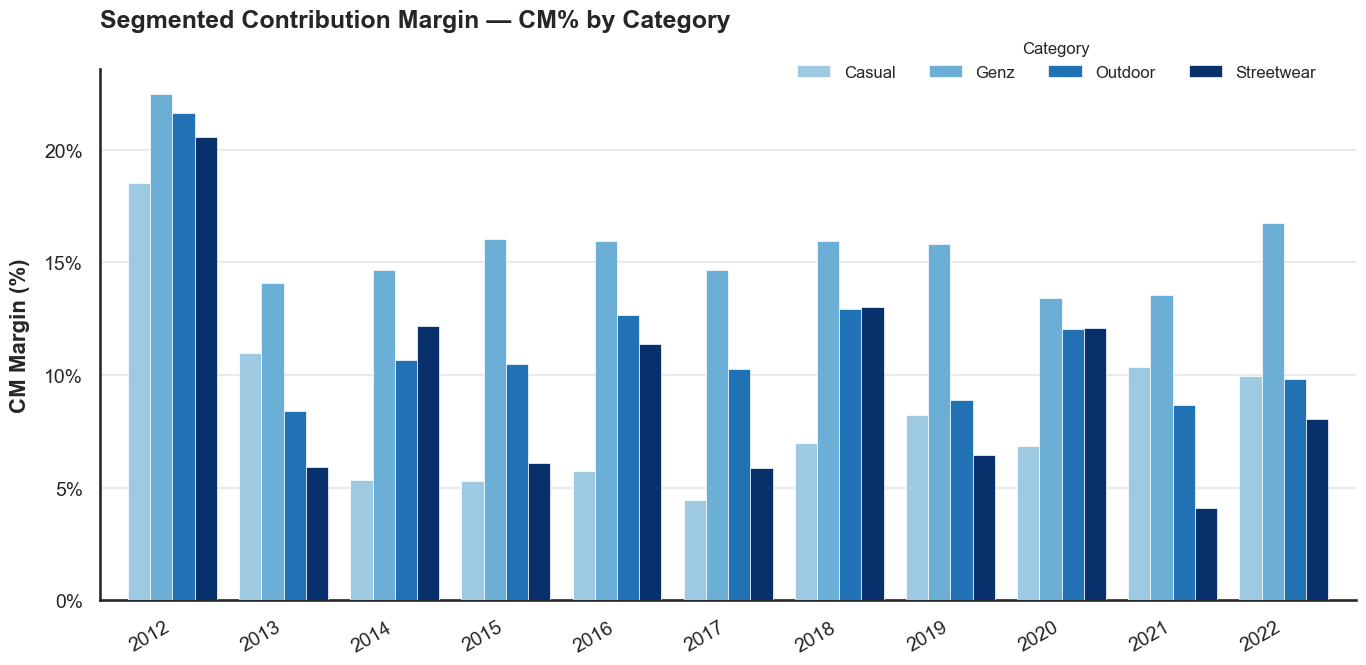

In [56]:
# 1. DATA PREP
oi = order_items.merge(products[["product_id", "category", "cogs"]], on="product_id", how="left")
oi["rev"] = oi["unit_price"] * oi["quantity"] - oi["discount_amount"]
oi["vc"]  = oi["cogs"] * oi["quantity"]
oi["cm"]  = oi["rev"] - oi["vc"]

oi = oi.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
oi["year"] = pd.to_datetime(oi["order_date"]).dt.year

# AGGREGATE
cm_df = (
    oi.groupby(["year", "category"])
    .agg(Revenue=("rev", "sum"), CM=("cm", "sum"))
    .reset_index()
    .assign(CM_pct=lambda d: d["CM"] / d["Revenue"] * 100)
)
cm_df = cm_df[(cm_df["year"] >= 2012) & (cm_df["year"] <= 2022)].copy()
cm_pivot_pct = cm_df.pivot(index="year", columns="category", values="CM_pct")

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7))
cat_colors = ['#9ECAE1', '#6BAED6', '#2171B5', '#08306B']

cm_pivot_pct.plot(
    kind='bar',
    color=cat_colors,
    width=0.8,
    edgecolor='white',
    linewidth=0.5,
    ax=ax,
    zorder=3
)

# TITLE & LABELS
ax.set_title(
    'Segmented Contribution Margin — CM% by Category',
    fontsize=18, fontweight='bold', loc='left', pad=30
)
ax.set_ylabel('CM Margin (%)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('')

# FORMATTING Y-AXIS
formatter = FuncFormatter(lambda x, pos: f'{int(x)}%')
ax.yaxis.set_major_formatter(formatter)

# LEGEND LAYOUT
ax.legend(
    title='Category',
    title_fontsize=12,
    fontsize=12,
    loc='upper right',
    bbox_to_anchor=(0.98, 1.08),
    ncol=4,
    frameon=False
)

# GRID & DESPINE
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
ax.grid(False, axis='x')
sns.despine(ax=ax, top=True, right=True)

# TICK FORMATTING
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

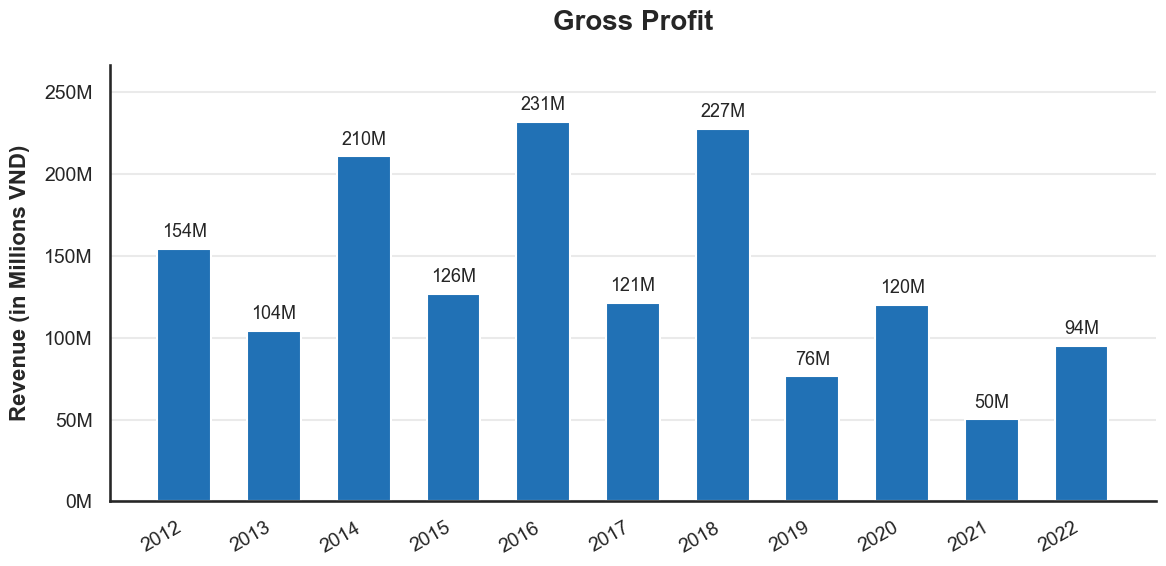

<Figure size 640x480 with 0 Axes>

In [57]:
# Chart 4 — Gross Profit
# 1. DATA PREP
oi["rev"] = oi["unit_price"] * oi["quantity"] - oi["discount_amount"]
oi["cogs_total"] = oi["cogs"] * oi["quantity"]

oi["gp"] = oi["rev"] - oi["cogs_total"]
oi["year"] = pd.to_datetime(oi["order_date"]).dt.year

gp_df = oi.groupby("year")["gp"].sum().reset_index()
gp_df = gp_df[(gp_df["year"] >= 2012) & (gp_df["year"] <= 2022)].copy()
gp_df.sort_values("year", inplace=True)

years = gp_df['year'].astype(str).tolist()
values = (gp_df['gp'] / 1e6).tolist()

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))

bar_color = '#2171B5'
bars = ax.bar(years, values, color=bar_color, width=0.6, edgecolor='white', linewidth=1.5, zorder=3)

# TITLE & LABELS
ax.set_title('Gross Profit', fontsize=20, fontweight='bold', pad=25)
ax.set_ylabel('Revenue (in Millions VND)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('')

# DATA LABELS
for i, bar in enumerate(bars):
    y_val = values[i]
    text_label = f"{int(y_val)}M"
    ax.text(bar.get_x() + bar.get_width()/2, y_val + (max(values) * 0.02),
            text_label, ha='center', va='bottom', fontsize=13)

# FORMATTING Y-AXIS
formatter = FuncFormatter(lambda x, pos: f'{int(x)}M' if x != 0 else '0M')
ax.yaxis.set_major_formatter(formatter)
ax.set_ylim(0, max(values) * 1.15)

# GRID & DESPINE
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
ax.grid(False, axis='x')
sns.despine(ax=ax, top=True, right=True)

ax.spines['bottom'].set_zorder(10)
ax.spines['left'].set_zorder(10)

# TICK FORMATTING
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

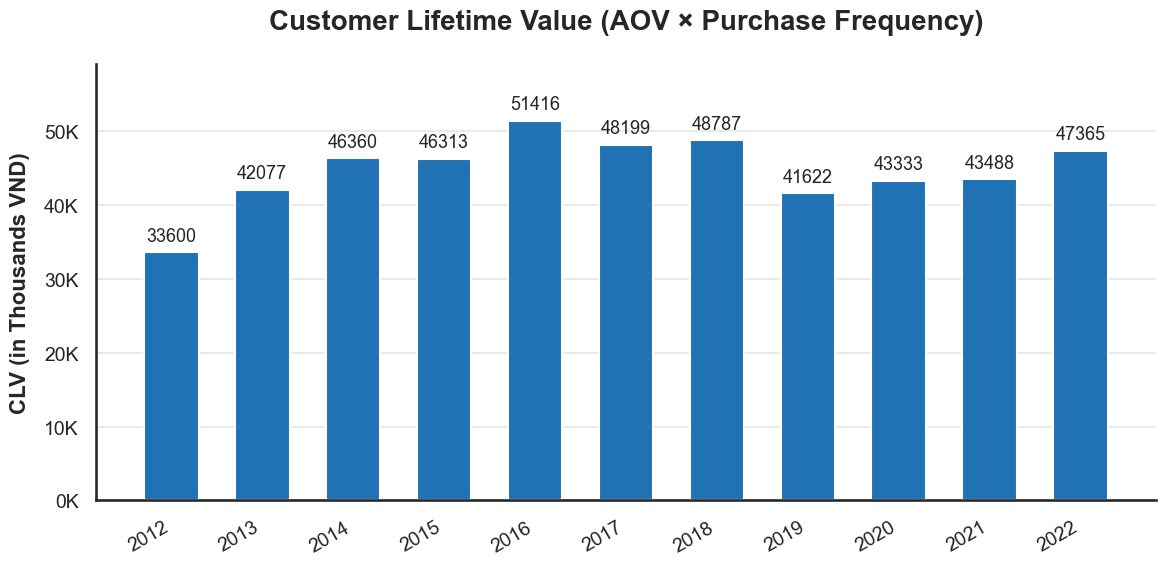

In [58]:
# 1. DATA PREP
sales["year"] = pd.to_datetime(sales["Date"]).dt.year
orders["year"] = pd.to_datetime(orders["order_date"]).dt.year

revenue_df = sales.groupby("year")["Revenue"].sum().reset_index()
orders_agg = orders.groupby("year").agg(
    total_orders=("order_id", "nunique"),
    unique_customers=("customer_id", "nunique")
).reset_index()

clv_df = pd.merge(revenue_df, orders_agg, on="year", how="inner")
clv_df["AOV"] = clv_df["Revenue"] / clv_df["total_orders"]
clv_df["Purchase_Frequency"] = clv_df["total_orders"] / clv_df["unique_customers"]
clv_df["CLV"] = clv_df["AOV"] * clv_df["Purchase_Frequency"]

clv_df = clv_df[(clv_df["year"] >= 2012) & (clv_df["year"] <= 2022)].copy()
clv_df.sort_values("year", inplace=True)

years = clv_df['year'].astype(str).tolist()
values = clv_df['CLV'].tolist()

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))
bar_color = '#2171B5'

bars = ax.bar(years, values, color=bar_color, width=0.6, edgecolor='white', linewidth=1.5, zorder=3)

# TITLE & LABELS
ax.set_title(
    'Customer Lifetime Value (AOV × Purchase Frequency)',
    fontsize=20, fontweight='bold', pad=25
)
ax.set_ylabel('CLV (in Thousands VND)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('')

# DATA LABELS
for i, bar in enumerate(bars):
    y_val = values[i]
    text_label = f"{int(y_val)}"

    ax.text(bar.get_x() + bar.get_width()/2, y_val + (max(values) * 0.02),
            text_label, ha='center', va='bottom', fontsize=13)

# FORMATTING Y-AXIS
formatter = FuncFormatter(lambda x, pos: f'{int(x/1000)}K' if x != 0 else '0K')
ax.yaxis.set_major_formatter(formatter)
ax.set_ylim(0, max(values) * 1.15)

# GRID & DESPINE
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
ax.grid(False, axis='x')
sns.despine(ax=ax, top=True, right=True)

ax.spines['bottom'].set_zorder(10)
ax.spines['left'].set_zorder(10)

# TICK FORMATTING
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

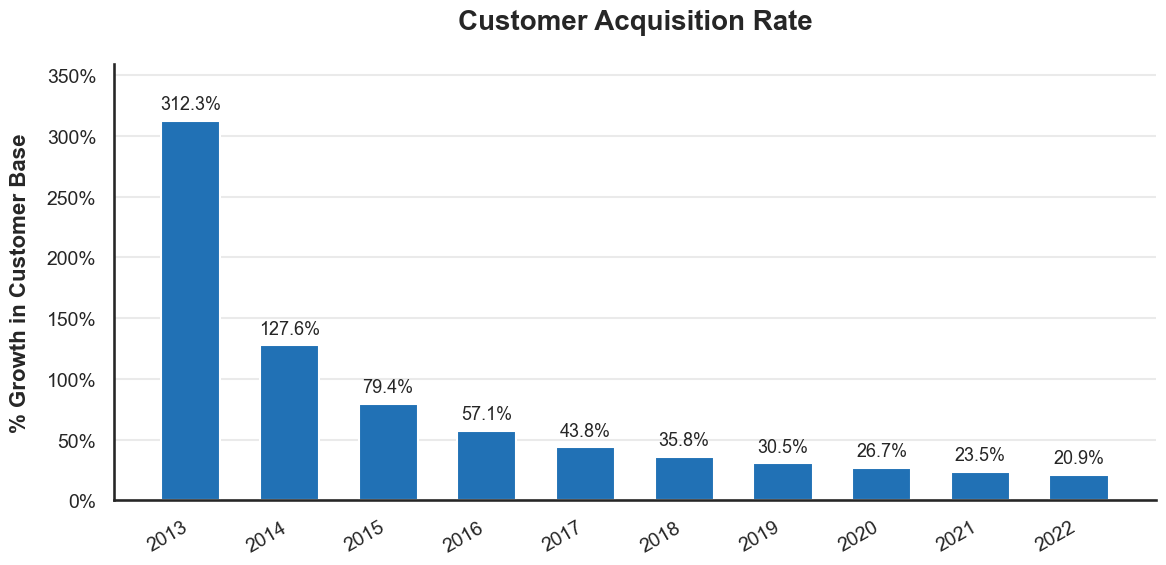

In [59]:
# 1. DATA PREP
customers["signup_year"] = pd.to_datetime(customers["signup_date"]).dt.year
new_per_year = customers.groupby("signup_year")["customer_id"].count().rename("new_customers")

cumulative = new_per_year.cumsum().shift(1).fillna(1)
# CAR
car = (new_per_year / cumulative * 100).rename("CAR").reset_index()
car = car[(car["signup_year"] >= 2013) & (car["signup_year"] <= 2022)].copy()

years = car['signup_year'].astype(str).tolist()
values = car['CAR'].tolist()

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))
bar_color = '#2171B5'

bars = ax.bar(years, values, color=bar_color, width=0.6, edgecolor='white', linewidth=1.5, zorder=3)

# TITLE & LABELS
ax.set_title('Customer Acquisition Rate', fontsize=20, fontweight='bold', pad=25)
ax.set_ylabel('% Growth in Customer Base', fontsize=16, fontweight='bold', labelpad=12)
ax.set_xlabel('')

# DATA LABELS
for i, bar in enumerate(bars):
    y_val = values[i]
    text_label = f"{y_val:.1f}%"
    ax.text(bar.get_x() + bar.get_width()/2, y_val + (max(values) * 0.02),
            text_label, ha='center', va='bottom', fontsize=13)

# FORMATTING Y-AXIS
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x)}%"))
ax.set_ylim(0, max(values) * 1.15)

# GRID & DESPINE
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
ax.grid(False, axis='x')
sns.despine(ax=ax, top=True, right=True)

ax.spines['bottom'].set_zorder(10)
ax.spines['left'].set_zorder(10)

# TICK FORMATTING
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

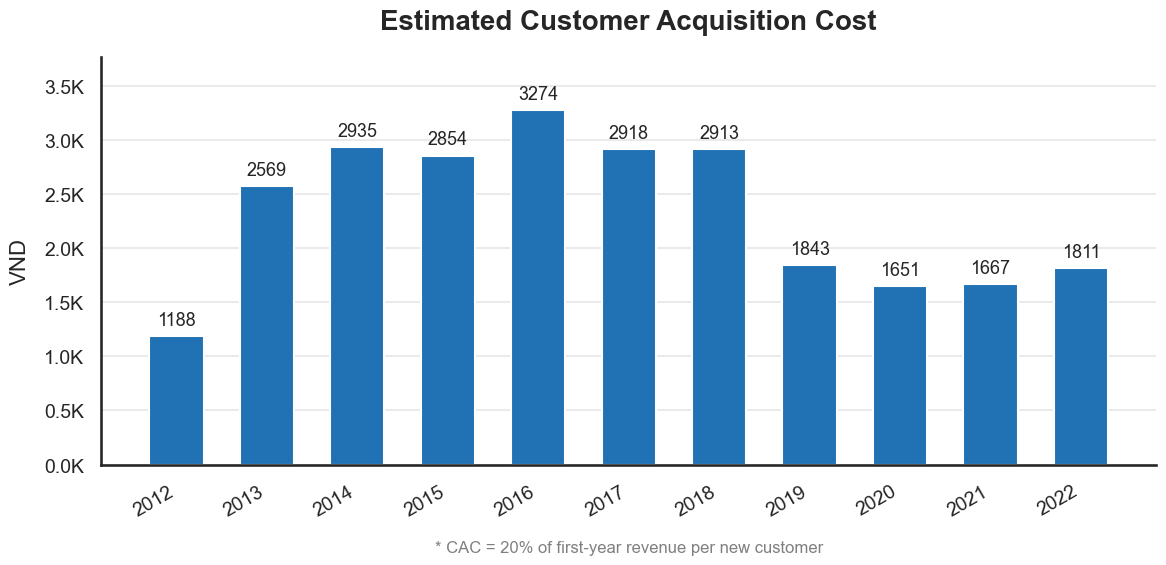

In [60]:
# 1. DATA PREP
customers["signup_year"] = pd.to_datetime(customers["signup_date"]).dt.year
orders["order_year"] = pd.to_datetime(orders["order_date"]).dt.year

new_customers = customers.groupby("signup_year")["customer_id"].count().rename("new_customers")
# FIRST-YEAR REVENUE
order_items["rev"] = order_items["unit_price"] * order_items["quantity"] - order_items["discount_amount"]
order_totals = order_items.groupby("order_id")["rev"].sum().reset_index()
orders_with_rev = orders.merge(order_totals, on="order_id", how="left")
orders_with_rev = orders_with_rev.merge(customers[["customer_id", "signup_year"]], on="customer_id", how="inner")

first_year_orders = orders_with_rev[orders_with_rev["order_year"] == orders_with_rev["signup_year"]]
first_year_rev = first_year_orders.groupby("signup_year")["rev"].sum().rename("first_year_revenue")

# CAC
cac_df = pd.DataFrame({
    "new_customers": new_customers,
    "first_year_revenue": first_year_rev
}).reset_index()
cac_df["CAC"] = (cac_df["first_year_revenue"] / cac_df["new_customers"]) * 0.20
cac_df = cac_df[(cac_df["signup_year"] >= 2012) & (cac_df["signup_year"] <= 2022)].copy()

years = cac_df['signup_year'].astype(str).tolist()
values = cac_df['CAC'].tolist()

# 2. VISUALIZATION
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6))
bar_color = '#2171B5'

bars = ax.bar(years, values, color=bar_color, width=0.6, edgecolor='white', linewidth=1.5, zorder=3)

# TITLE & LABELS
ax.set_title('Estimated Customer Acquisition Cost', fontsize=20, fontweight='bold', pad=20)
ax.set_ylabel('VND', fontsize=16, labelpad=10)
ax.set_xlabel('* CAC = 20% of first-year revenue per new customer', fontsize=12, color='gray', labelpad=15)

# DATA LABELS
for i, bar in enumerate(bars):
    y_val = values[i]
    text_label = f"{int(y_val)}"
    ax.text(bar.get_x() + bar.get_width()/2, y_val + (max(values) * 0.02),
            text_label, ha='center', va='bottom', fontsize=13)

# FORMATTING Y-AXIS
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K"))
ax.set_ylim(0, max(values) * 1.15)

# GRID & DESPINE
ax.grid(True, axis='y', linestyle='-', alpha=0.4, zorder=0)
ax.grid(False, axis='x')
sns.despine(ax=ax, top=True, right=True)

ax.spines['bottom'].set_zorder(10)
ax.spines['left'].set_zorder(10)

# TICK FORMATTING
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()